# Taller 1 · Del voltaje crudo a la figura

**De la neurona a la figura** · Análisis neuronal en insectos asistido por IA

| | |
|---|---|
| **Cuándo se trabaja** | martes 18 (2 h) y jueves 20 de agosto de 2026 (1 h) |
| **Entrega** | martes 25 de agosto de 2026, completo |
| **Modalidad** | en parejas · versionado en GitHub |
| **Valor** | 15 % de la nota final |
| **Datos** | registro extracelular sintético de **un electrodo**, generado para este curso |

---

Tienen el voltaje registrado por **un electrodo** dentro de un tejido nervioso. Dentro de
ese archivo hay tres neuronas disparando, ruido de varias clases, y un protocolo de
estimulación con tres condiciones repetidas veinte veces cada una.

Al terminar, este taller responderá a una pregunta concreta:
**¿qué neurona responde a qué estímulo?** Todo lo que hay en medio (diagnosticar, filtrar,
detectar, separar, alinear, promediar) son los pasos de un pipeline que van a repetir, con
variantes, el resto del curso y en el proyecto final.

Este taller **junta la práctica de la Sesión 4 con el Taller 1**: el ruido de red, el
espectro y las dos bandas ya no son un ejercicio aparte, sino el paso 3 y 4 de este mismo
pipeline. Filtran una vez, y esa señal filtrada es la que usan hasta el final.

## Por qué los datos son sintéticos

Los generamos nosotros, así que **sabemos exactamente dónde está cada disparo y de qué
neurona viene**. Eso significa que su código puede compararse contra la verdad y que
ustedes reciben un número objetivo que dice si acertaron.

Con datos reales eso no existe: nadie sabe cuál es la respuesta correcta. Este taller es el
único momento del curso en que pueden preguntarle a su propio análisis si está bien y
obtener una respuesta.

## Cómo se usa la IA aquí

Pueden y **deben** usar ChatGPT o Claude. No se evalúa que memoricen sintaxis: eso lo
resuelve el modelo. Se evalúa que entiendan lo que devuelve y que sepan comprobarlo.

1. **Especifiquen, no deleguen.** Pidan piezas con entradas y salidas definidas ("una
   función que reciba esto y devuelva esto otro"), no el ejercicio completo. La
   especificación es suya; la implementación puede ser del modelo.
2. **Verifiquen siempre.** Cada ejercicio numérico tiene una celda ✅ que compara su
   resultado contra la verdad. Un código que corre sin error no es un código correcto.
3. **Documenten la conversación.** Al final registran al menos **tres** intercambios: el
   prompt, lo que devolvió el modelo, qué estaba mal y cómo lo corrigieron. Se califica.
   Si el modelo nunca se equivocó, es que no están mirando con suficiente atención.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.** En la sustentación del
proyecto final les vamos a preguntar por su propio código.

### Los 5 elementos de un prompt de programación

1. **Lenguaje.** Python. (Basta decirlo una vez, al inicio del chat.)
2. **Tipo de tarea.** Graficar, filtrar, detectar, comparar, calcular.
3. **Subtipo.** Espectro con Welch, Butterworth de fase cero, notch a 60 Hz, umbral robusto.
4. **Tipo de datos.** *"Un array de numpy con 4,2 millones de muestras de voltaje en µV,
   muestreado a 20 000 Hz, donde los disparos son picos negativos."*
5. **Exigencias de calidad.** Ejes rotulados con unidades, que explique qué hace cada
   línea, que no use librerías extra.

### Los iconos

| | Ejercicio | Qué hacen |
|---|---|---|
| ✏️ | **Completar el código** | La celda tiene huecos marcados con `____`. No corre hasta que los llenen. |
| 📋 | **Pegar este prompt** | Cópienlo tal cual, lean la respuesta y decidan si sirve **antes** de usarla. |
| ✍️ | **Escribir su prompt** | Lo redactan ustedes, con los 5 elementos. Va en la celda de texto: **hace parte de la entrega**. |
| ✅ | **Verificación** | Les dice si el resultado es correcto, no cómo llegar a él. |

## Qué traen de las sesiones anteriores

Este taller junta en un solo pipeline lo que han visto hasta ahora y lo aplica a un
registro completo (210 segundos, tres neuronas y un protocolo experimental) en vez de a una
señal de juguete de dos segundos.

| Del Lab 1 (11 ago) | De la Sesión 3 (13 ago) | De la Sesión 4 (14 ago) |
|---|---|---|
| Python: variables, funciones, ciclos | `ver()`, mirar una ventana de señal | qué es el ruido de red, la deriva y el ruido térmico |
| cómo pedirle código a la IA y corregirlo | umbral robusto con MAD | qué es el espectro de potencia y para qué se mira |
| Colab y GitHub | período muerto | las dos bandas: LFP (< 300 Hz) y AP (> 300 Hz) |
| | `detectar()`, índices de disparo | filtros: pasa-banda, pasa-bajos y notch |

**Abran su notebook de la Sesión 3 en otra pestaña.** De ahí van a copiar `ver()` y
`detectar()`: copiar y adaptar el propio código es lo que se hace en un laboratorio real,
y escribirlo dos veces es perder el tiempo.

**De la Sesión 4 traen las ideas, no el código.** No alcanzamos a hacer la práctica, así
que `espectro()`, `filtrar()` y el `notch()` se escriben hoy por primera vez, con ayuda de
la IA y con la especificación que les damos en cada ejercicio. Eso es justamente lo que
van a tener que hacer solos en el proyecto final: saber qué necesitan y pedirlo bien.

**Y lo que es nuevo aquí, que es lo que se evalúa:** medir si su detección acertó, separar
las tres neuronas, y llevar los tiempos de disparo hasta una figura que responda una
pregunta.

**Abran sus notebooks de la Sesión 3 y la Sesión 4 en otra pestaña.** Van a copiar de ahí
`ver()`, `espectro()`, `filtrar()` y `detectar()`. Copiar y adaptar el propio código es lo
que se hace en un laboratorio real; escribirlo dos veces es perder el tiempo.

## Cómo se reparten las dos sesiones

| | Martes 18 · 2 h | Jueves 20 · 2 h |
|---|---|---|
| | A · Abrir el archivo y explorarlo | H · Separar las tres unidades |
| | B · Mirar la señal y encontrar sus tres problemas | I · ISI como control de calidad |
| | C · Diagnosticar el ruido con el espectro | J y K · Protocolo y alineación al estímulo |
| | D · Filtrar: banda AP y banda LFP | L y M · Raster y PSTH |
| | E · Detectar los disparos ← *el ejercicio central* | N · Heatmap multiunidad |
| | F · Medir si acertaron: VP, FP y FN | O y P · Conclusión y figura final |
| | G · Formas de onda | Q · Documentar la conversación con la IA |

⏱ **Punto de control** al final de la sección F. Si la detección no quedó, hay una celda
que carga tiempos correctos para poder seguir. Usarla no penaliza lo que viene después,
pero **hay que anotarlo en la entrega**.

## Qué se entrega y cómo se califica

En el repositorio de GitHub de la pareja, en una carpeta `taller1/`:

| Archivo | Qué debe contener |
|---|---|
| `Taller1_ApellidoUno_ApellidoDos.ipynb` | este notebook ejecutado, con todas las figuras visibles y las celdas de texto contestadas |
| `spikes_taller1.csv` | dos columnas: `tiempo_s` y `unidad` |
| `figuras/` | las figuras exportadas en PNG, incluida `figura_final.png` |
| `README.md` | quiénes son, qué hicieron y cómo ejecutar el notebook desde cero |

**Plazo: martes 25 de agosto de 2026.** El `README.md` no es un trámite: escríbanlo
pensando en alguien que llega al repositorio sin haber estado en clase y quiere reproducir
lo que hicieron.

## Rúbrica de evaluación (Taller 1)

### Ejercicios:

| Ejercicio | Puntos | Qué se busca |
|---|---|---|
| A1 | 0,5 | Explorar el archivo HDF5 con código: atributos, número de ensayos, condiciones y estructura del ensayo. |
| B1 y B2 | 0,5 | Graficar la señal cruda a tres escalas, encontrar los tres problemas y decir cuál impide contar los disparos a ojo. |
| C1 | 1,0 | Escribir el prompt y la función `espectro()`, con eje logarítmico y ejes rotulados. |
| C2 | 0,5 | Interpretar el espectro: resolución del análisis, armónico de la red, por qué la deriva no aparece y para qué sirve la escala logarítmica. |
| D1 | 1,0 | Escribir el prompt y la función `filtrar()`, con fase cero y frecuencias normalizadas por Nyquist, y obtener la banda AP. |
| D2 | 0,5 | Explicar por qué el pasa-banda hace el trabajo del notch en este registro y cuándo sí haría falta un notch. |
| D3 | 0,5 | Aplicar el notch de 60 y 120 Hz al LFP a partir del prompt dado, corrigiendo lo que el modelo devuelve mal. |
| D4 | 0,5 | Los tres experimentos de filtrado (notch en 9 Hz, Q = 2, cortes en 100 y 800 Hz) y la conclusión sobre el orden diagnóstico y filtrado. |
| E1 | 2,5 | La función de detección. Resuelve las cuatro decisiones: signo del evento, umbral robusto relativo al ruido, un solo índice por cruce y período muerto. |
| E2 | 0,5 | La figura de control con la señal, el umbral y un marcador sobre cada disparo detectado. |
| F1 | 1,5 | La función de emparejamiento y los tres números VP, FP y FN, con tolerancia y sin reutilizar disparos reales. Coincide con el módulo de verificación. |
| F2 | 1,0 | El barrido de k con las curvas de precisión, exhaustividad y F1, y la elección de k argumentada como un compromiso. |
| F3 | 0,5 | Separar con datos los dos orígenes de los falsos negativos y discutir el período muerto frente al refractario. |
| G1 | 0,5 | Extraer las ventanas de forma de onda y graficarlas superpuestas con su promedio. |
| H1 y H2 | 2,0 | Elegir dos características que separen las tres unidades, agrupar, justificar la elección y leer la matriz de confusión comparando con el resultado de usar solo amplitud. |
| I1 | 1,0 | El ISI como control de calidad: violaciones del refractario del conjunto y por unidad, histogramas y efecto del período muerto corto. |
| J1 | 0,5 | Leer el protocolo experimental del archivo y responder con código sobre ensayos, condiciones y estructura temporal. |
| K1 y K2 | 1,5 | La función de alineación al inicio del estímulo y la comprobación a mano de un ensayo. Es el paso donde el error no produce ningún aviso. |
| L1 y L2 | 0,5 | El raster de tres paneles con las condiciones distinguibles y la ventana del estímulo marcada, y su lectura. |
| M1 y M2 | 1,0 | La función `psth()` con la tasa en hercios y el PSTH de cada unidad y condición. |
| M3 | 0,5 | El efecto del ancho del bin con los cuatro anchos y la elección argumentada. |
| N1 y N2 | 1,0 | El heatmap multiunidad con las tres decisiones justificadas (escala de color, barra con unidades, marca del estímulo) y su lectura. |
| O1 y O2 | 1,5 | La figura final de cuatro paneles con las reglas de figura científica y su pie de figura. |
| P1 | 1,0 | El párrafo de resultados con cifras concretas, referencia a una figura, una incertidumbre reconocida y las cifras de calidad propias. |
| Q1 | 1,0 | Los tres intercambios documentados con la IA: prompt, respuesta, qué estaba mal y cómo se corrigió. |
| **Total** | **23,0** | |

### Criterios generales:

| Criterio | Puntos | Qué se busca | Cuándo se pierde |
|---|---:|---|---|
| **1. El notebook corre de principio a fin** | 1,5 | Reiniciar y ejecutar todo llega al final sin un solo error. No queda ningún hueco `____` sin llenar ni ningún `...` sin reemplazar. | Media si hay que arreglar algo a mano para que corra. Cero si no corre. |
| **2. Las verificaciones dicen OK** | 1,5 | Todas las celdas de verificación del notebook salen en **OK**. | Una verificación en **FALLA** no descuenta si el estudiante explica en una celda de texto por qué falla y qué intentó. Sin esa explicación, media. |
| **3. Figuras legibles** | 1,5 | Los dos ejes rotulados, con nombre y unidad. Leyenda cuando hay más de una serie. Título que dice qué se está viendo. Texto legible al exportar a PNG. Escalas comparables cuando la figura invita a comparar paneles. | Media si falta la unidad o la leyenda en alguna figura. Cero si las figuras no permiten leer el resultado. |
| **4. Código explicado** | 1,0 | Cada función escrita por ellos tiene un docstring de una línea. Los comentarios dicen el porqué, no el qué. Los números mágicos (300 Hz, 0,6745, 1,5 ms) llevan su justificación. Las unidades están escritas. No quedan celdas muertas de pruebas a medias. | Media si el código corre pero está sin comentar. Cero si hay bloques que no pueden explicar. |
| **5. Prompts donde se piden** | 1,0 | En los ejercicios marcados como «escriban su prompt», el que escribieron está copiado en la celda de texto. En los marcados como «peguen este prompt», se indica qué le corrigieron a la respuesta del modelo. En los demás ejercicios no se piden prompts. | Proporcional a cuántos faltan. |
| **6. Repositorio y entrega** | 0,5 | Carpeta del taller en el repositorio de la pareja, archivo con el nombre pedido, figuras exportadas y README que permite reproducir el trabajo desde cero. | Media si falta el README o si el repositorio no tiene estructura. |
| **Total** | **7** | |

| **Total completo** | **30** | |

---
## 0 · Preparación

Ejecuten esta celda primero. Se las damos hecha: descarga los dos archivos del taller,
importa las librerías, fija el estilo de las figuras y define dos ayudas que van a usar
todo el tiempo: `revisar()`, que comprueba resultados, y `pot()`, que mide cuánta potencia
tiene una señal en un rango de frecuencias.

In [78]:
# ---------------------------------------------------------------
# Preparación del entorno. Ejecútenla y sigan.
# ---------------------------------------------------------------
ID_DATOS = "1JlXu_uQ19yM4AEEVlAUravO0CA_PHScZ"      # <-- id de taller1_datos.h5   (lo da el docente)
ID_VERIF = "1CWca52MHI44n8SEv6_ARcc3hYO0pG3qk"      # <-- id de verificacion.py    (lo da el docente)

import os
for fid, nombre in [(ID_DATOS, "taller1_datos.h5"), (ID_VERIF, "verificacion.py")]:
    if fid and not os.path.exists(nombre):
        import gdown
        gdown.download(id=fid, output=nombre, quiet=True)
        print("descargado:", nombre)

# Si prefieren, suban los dos archivos a mano con el panel de archivos de Colab
# (icono de carpeta a la izquierda) y dejen los dos ID vacíos.

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import h5py
from scipy.signal import butter, filtfilt, welch, iirnotch

# Estilo del curso
NAVY, TEAL, ORANGE, GRAY = "#0E2841", "#156082", "#E97132", "#6E6E6E"
plt.rcParams.update({"figure.figsize": (12, 3.4), "figure.dpi": 110,
                     "axes.spines.top": False, "axes.spines.right": False,
                     "font.size": 11})
os.makedirs("figuras", exist_ok=True)

def revisar(nombre, condicion, pista=""):
    """Imprime si una comprobación pasó. No dice cómo arreglarla, solo qué falla."""
    print(("  OK    " if condicion else "  FALLA ") + nombre +
          (("  ->  pista: " + pista) if (not condicion and pista) else ""))

def pot(x, f0, f1, fs=20000):
    """Potencia de la señal x entre f0 y f1 Hz (suma del espectro en ese rango)."""
    f, P = welch(x, fs, nperseg=8192)
    return float(P[(f >= f0) & (f < f1)].sum())

print("Listo.")

Listo.


---
## A · Abrir el archivo y averiguar qué contiene

La celda de carga se las regalamos. **Léanla antes de ejecutarla:** la estructura de este
archivo es la misma de los datos públicos que usarán en el proyecto final, y entenderla
ahora les ahorra una tarde en septiembre.

Un archivo HDF5 se organiza como carpetas dentro de un archivo:

```
taller1_datos.h5
├── atributos del archivo   (frecuencia de muestreo, escala, duración…)
├── registro/
│   └── canal_0             ← un arreglo de enteros: el voltaje del electrodo
├── estimulos/
│   ├── tiempo_inicio_s     ← cuándo empieza cada ensayo
│   └── condicion           ← qué estímulo se presentó en cada ensayo
└── verdad/                 ← la usa verificacion.py; no la miren todavía
```

Dos detalles que importan:

- El voltaje **no** está en microvoltios: está en enteros de 16 bits, tal como sale de la
  tarjeta de adquisición. Hay que multiplicarlo por `escala_uV_por_bit`. Si se saltan ese
  paso, todos sus umbrales van a estar cinco veces mal y nada les va a avisar.
- `tiempo_inicio_s` marca el inicio del **ensayo**, no el del **estímulo**. Guárdense ese
  dato: es la trampa de la sección K.

In [79]:
# ---------- CELDA REGALADA: carga ----------
ARCHIVO = "taller1_datos.h5"

with h5py.File(ARCHIVO, "r") as f:
    fs     = int(f.attrs["frecuencia_muestreo_hz"])
    escala = float(f.attrs["escala_uV_por_bit"])
    cruda  = f["registro/canal_0"][:].astype(np.float32) * escala   # ahora sí, en µV

t = np.arange(len(cruda)) / fs          # eje temporal en segundos
print(f"{fs} Hz · {len(cruda)/fs:.1f} s · {len(cruda)} muestras · "
      f"rango {cruda.min():.0f} a {cruda.max():.0f} µV")

20000 Hz · 210.0 s · 4200000 muestras · rango -664 a 456 µV


### ✏️ Ejercicio A1 · Explorar el archivo

Antes de tocar la señal, averigüen qué más hay dentro. Contesten **con código, no de
memoria**:

- ¿Qué atributos tiene el archivo y qué dice cada uno?
- ¿Qué hay dentro del grupo `estimulos`? ¿Cuántos ensayos hay?
- ¿Cuántas condiciones distintas de estímulo se presentaron?
- ¿Cuánto dura un ensayo, y cuánto dura el estímulo dentro de él? *(Está en los atributos
  del grupo `estimulos`, no en los del archivo.)*

*Pista para el prompt: pídanle a la IA cómo recorrer y listar el contenido de un archivo
HDF5 con `h5py`, incluyendo los atributos de cada grupo.*

In [80]:
import h5py
import numpy as np

ARCHIVO = "taller1_datos.h5"

def mostrar_atributos(obj, indent=""):
    """Imprime los atributos de un grupo/dataset, si tiene."""
    if len(obj.attrs) == 0:
        return
    for clave, valor in obj.attrs.items():
        print(f"{indent}    @{clave} = {valor}")

def explorar(nombre, obj):
    """Callback usado por visititems: se ejecuta para cada grupo/dataset."""
    nivel = nombre.count("/")
    indent = "  " * nivel
    tipo = "Grupo" if isinstance(obj, h5py.Group) else "Dataset"
    extra = f"  shape={obj.shape} dtype={obj.dtype}" if isinstance(obj, h5py.Dataset) else ""
    print(f"{indent}📁 {nombre}  [{tipo}]{extra}")
    mostrar_atributos(obj, indent)

with h5py.File(ARCHIVO, "r") as f:
    print("=== ATRIBUTOS DEL ARCHIVO (raíz) ===")
    mostrar_atributos(f, indent="")
    print("\n=== ESTRUCTURA DEL ARCHIVO ===")
    print(f"📁 /  [Grupo raíz]")
    f.visititems(explorar)

=== ATRIBUTOS DEL ARCHIVO (raíz) ===
    @descripcion = Registro extracelular sintetico de un canal. Curso: De la neurona a la figura, Taller 1.
    @duracion_s = 210.0
    @escala_uV_por_bit = 0.195
    @frecuencia_muestreo_hz = 20000
    @n_canales = 1
    @unidades = microvoltios tras multiplicar por escala_uV_por_bit

=== ESTRUCTURA DEL ARCHIVO ===
📁 /  [Grupo raíz]
📁 estimulos  [Grupo]
    @duracion_estimulo_s = 0.5
    @duracion_post_s = 1.5
    @duracion_pre_s = 1.0
    @nota = tiempo_inicio_s marca el inicio del ENSAYO. El estimulo empieza duracion_pre_s despues de ese instante.
  📁 estimulos/condicion  [Dataset]  shape=(60,) dtype=|S1
  📁 estimulos/tiempo_inicio_s  [Dataset]  shape=(60,) dtype=float64
📁 registro  [Grupo]
  📁 registro/canal_0  [Dataset]  shape=(4200000,) dtype=int16
📁 verdad  [Grupo]
    @nota = Tiempos reales de espiga. Los usa verificacion.py.
  📁 verdad/artefactos_s  [Dataset]  shape=(4,) dtype=float64
  📁 verdad/tiempos_s  [Dataset]  shape=(5623,) dtype=flo

In [81]:
with h5py.File(ARCHIVO, "r") as f:
    condiciones = f["estimulos/condicion"][:]
    condiciones_decodificadas = [c.decode() for c in condiciones]
    valores_unicos, conteos = np.unique(condiciones_decodificadas, return_counts=True)

    print(f"N° de ensayos: {len(condiciones)}")
    print(f"Condiciones únicas: {list(valores_unicos)}")
    print(f"Conteo por condición: {dict(zip(valores_unicos, conteos))}")

N° de ensayos: 60
Condiciones únicas: [np.str_('A'), np.str_('B'), np.str_('C')]
Conteo por condición: {np.str_('A'): np.int64(20), np.str_('B'): np.int64(20), np.str_('C'): np.int64(20)}


**Lo que encontramos en el archivo:**

- ensayos: 60
- condiciones: np.str_('A'), np.str_('B'), np.str_('C'
- duración del ensayo: 210 s · pre-estímulo: 1 s · estímulo: 0.5 s

---
## B · Mirar antes de calcular

**Nunca** analicen una señal que no han graficado.

### ✏️ Ejercicio B1 · Mirar la señal a tres escalas

Reconstruyan su función `ver()` de la Sesión 3 (grafica solo la ventana de tiempo que le
pidan) y úsenla para mirar la señal cruda a tres escalas distintas:

- **un segundo** en cualquier tramo que no sea el principio del registro;
- **cincuenta milisegundos** dentro de ese mismo segundo;
- **el registro completo**, muy comprimido.

**Hay tres problemas distintos en esta señal.** Un problema se ve en la escala de un segundo, otro
solo aparece cuando miran el registro entero, y el tercero son eventos aislados y enormes.
Encuéntrenlos y descríbanlos abajo. No sigan hasta tener los tres.

*Ojo con un detalle que ya conocen: `ver()` no llama a `plt.show()`. En Colab la figura se
dibuja sola al final de la celda, y así pueden seguir añadiéndole cosas (una línea de
umbral, unos marcadores) después de llamarla.*

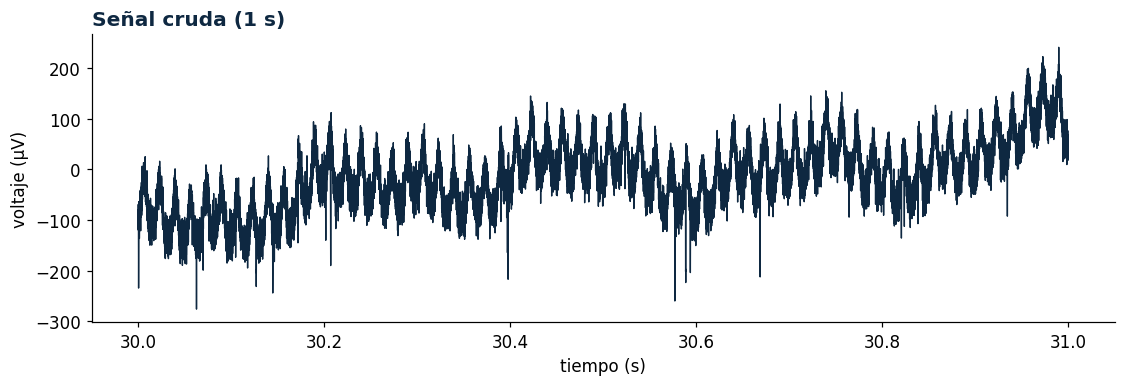

In [82]:
def ver(x, titulo, t0=30.0, t1=31.0, color=NAVY):
    """Grafica la señal x entre los tiempos t0 y t1 (en segundos)."""
    m = (t >= t0) & (t < t1)                  # máscara: True donde el tiempo cae en la ventana: se agrego t1
    plt.figure()
    plt.plot(t[m], x[m], color=color, lw=0.9)   # ¿qué va en el eje x y qué en el eje y? Se agregó t[m],x[m] donde se acortan ambas a los valores de tiempo en True
    plt.title(titulo, color=NAVY, fontweight="bold", loc="left")
    plt.xlabel("tiempo (s)")                          # no olvides las unidades
    plt.ylabel("voltaje (µV)")
    # Su código aquí: máscara de la ventana, plot, título y ejes CON UNIDADES
    ...


ver(cruda, "Señal cruda (1 s)", t0=30.0, t1=31.0)

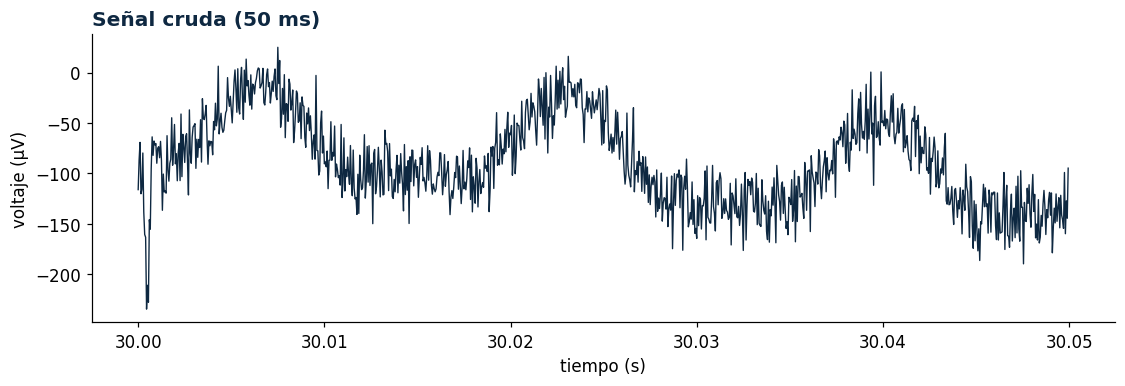

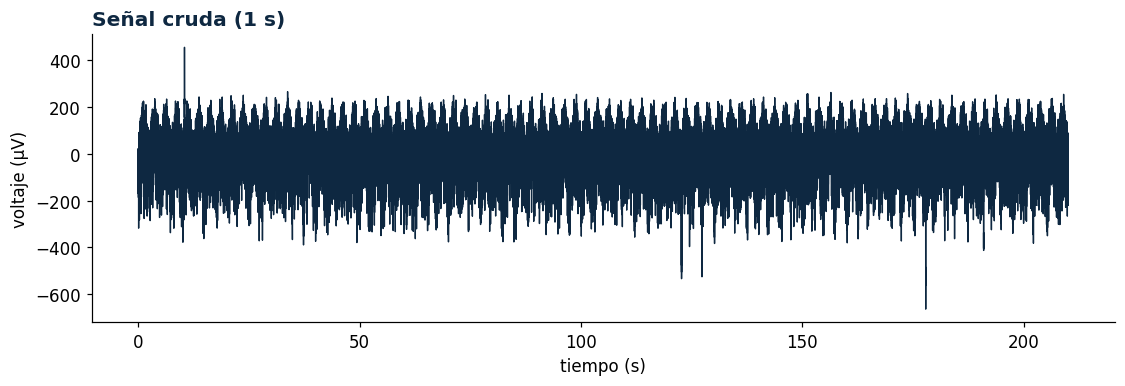

In [83]:
# Su código aquí: los otros dos zooms (50 ms y el registro completo).
ver(cruda, "Señal cruda (50 ms)", t0=30.0, t1=30.05) #50ms
ver(cruda, "Señal cruda (1 s)", t0=0.0, t1=210.0) #Registro completo

**Los tres problemas que encontramos:**

1. Mucho ruido
2.
3.

**Pregunta B2.** ¿Cuál de los tres nos impide contar los disparos a ojo, como hicimos en la Sesión 3? En realidad las ondas manejan una amplitud similiar sean ruido o picos.

---
## C · Diagnosticar el ruido: el espectro de potencia

Mirar la señal en el tiempo les dice que *hay* algo raro. El **espectro de potencia** les
dice **qué** es: cuánta energía tiene la señal en cada frecuencia. Es la herramienta de
diagnóstico, y se mira **antes** de filtrar nada, porque un filtro que no hacía falta
también deforma la señal.

Qué van a buscar en él:

| En el espectro | Qué es |
|---|---|
| un **pico angosto** en una frecuencia exacta | algo instrumental: la red eléctrica |
| energía en las **frecuencias muy bajas** (< 5 Hz) | la deriva lenta |
| energía entre **300 y 3000 Hz** | los potenciales de acción |
| un **piso plano** que nunca baja | ruido térmico, presente en todas las frecuencias |

### ✍️ Ejercicio C1 · Escriban su prompt
Necesitan una función `espectro()`. En la Sesión 4 vimos **para qué** sirve el espectro y
qué se busca en él; programarlo es de hoy. Especificación:

| | |
|---|---|
| **Entradas** | `x` (array de voltaje), `fs` (frecuencia de muestreo), `etiqueta` (título), `fmax=500` |
| **Salida** | dos arrays: `f` (frecuencias, Hz) y `P` (potencia en cada frecuencia) |
| **Cómo** | con `scipy.signal.welch` y `nperseg=8192`; graficar solo hasta `fmax`, con el eje y en escala logarítmica (`plt.semilogy`), ejes rotulados con unidades |

Antes de escribirlo, repasen los **5 elementos**. Un prompt que solo diga *"hazme un
espectro"* devuelve algo que no encaja con estos datos.

_Escriban aquí su prompt:_


> Para crear una función espectro().
Las entradas son:	x (array de voltaje), fs (frecuencia de muestreo), etiqueta (título), fmax=500. La salida debe ser:	Dos arrays: f (frecuencias, Hz) y P (potencia en cada frecuencia). Utilice como método scipy.signal.welch y nperseg=8192; grafica solo hasta fmax, con el eje y en escala logarítmica (plt.semilogy), ejes rotulados con unidades.

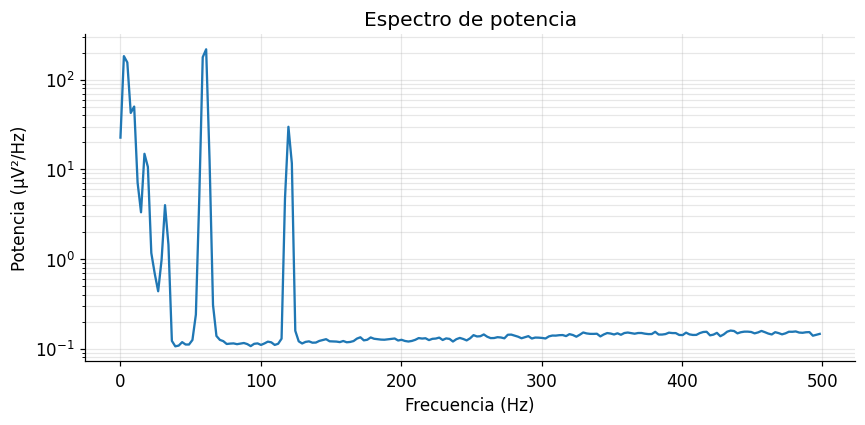

Pico dominante entre 40 y 200 Hz: 61.0 Hz


In [88]:
# Su código aquí: peguen o escriban espectro() y aplíquenla a la señal cruda.
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

def espectro(x, fs, etiqueta, fmax=500):
    """
    Calcula y grafica el espectro de potencia de una señal usando el método
    de Welch.

    Parámetros
    ----------
    x       : array de voltaje (µV), la señal en el dominio del tiempo
    fs      : frecuencia de muestreo (Hz)
    etiqueta: título para el gráfico
    fmax    : frecuencia máxima a graficar (Hz), por defecto 500

    Retorna
    -------
    f : array de frecuencias (Hz)
    P : array de potencia (µV²/Hz) en cada frecuencia
    """
    f, P = welch(x, fs=fs, nperseg=8192)

    # Máscara para graficar solo hasta fmax
    mascara = f <= fmax

    plt.figure(figsize=(8, 4))
    plt.semilogy(f[mascara], P[mascara])
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Potencia (µV²/Hz)")
    plt.title(etiqueta)
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return f, P
# Al final tienen que quedar definidas estas dos variables:

f, P = espectro(cruda,fs,"Espectro de potencia")      # llamen a su función aquí

# Esta línea dice cuál es la frecuencia con más potencia entre 40 y 200 Hz:
m = (f > 40) & (f < 200)
pico = float(f[m][np.argmax(P[m])])
print(f"Pico dominante entre 40 y 200 Hz: {pico:.1f} Hz")

In [89]:
# ✅ VERIFICACIÓN · ejercicio C1
revisar("espectro() devuelve dos arrays del mismo tamaño",
        len(f) == len(P) and len(f) > 100,
        "welch devuelve (frecuencias, potencias): hay que retornar las dos")
revisar("las frecuencias llegan hasta Nyquist (10 000 Hz)",
        f.max() > 9000,
        "grafiquen solo hasta fmax, pero calculen el espectro completo")
revisar("el pico dominante está en la red eléctrica (~60 Hz)",
        55 < pico < 65,
        "revisen que le pasaron fs a welch y no el valor por defecto")
revisar("la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)",
        pot(cruda, 55, 65, fs) > 2 * pot(cruda, 5, 15, fs))
revisar("hay energía en la banda de los potenciales de acción",
        pot(cruda, 300, 3000, fs) > 0)

  OK    espectro() devuelve dos arrays del mismo tamaño
  OK    las frecuencias llegan hasta Nyquist (10 000 Hz)
  OK    el pico dominante está en la red eléctrica (~60 Hz)
  OK    la potencia se concentra en 60 Hz más que en la banda del LFP (5-15 Hz)
  OK    hay energía en la banda de los potenciales de acción


In [86]:
#Utilizando esta celda de la práctica 4
f[1]-f[0]==2.44140625
for_bin=f[1]-f[0]

60/for_bin
bin_one=24
bin_two=25

dato_intervalo_one=f[bin_one]
dato_intervalo_two=f[bin_two]

print(f[1]-f[0]==2.44140625)
print(for_bin)
print(str(dato_intervalo_one)+" Hz - "+ str(dato_intervalo_two)+" Hz")

True
2.44140625
58.59375 Hz - 61.03515625 Hz


In [87]:
nperseg = 8192
nperseg / fs

0.4096

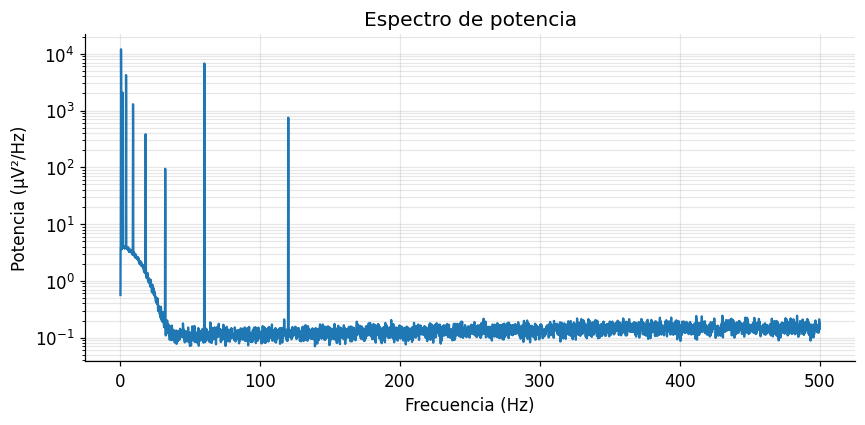

Pico dominante entre 40 y 200 Hz: 60.0 Hz


In [31]:
# Su código aquí: peguen o escriban espectro() y aplíquenla a la señal cruda.
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import welch

def espectro(x, fs, etiqueta, fmax=500):
    """
    Calcula y grafica el espectro de potencia de una señal usando el método
    de Welch.

    Parámetros
    ----------
    x       : array de voltaje (µV), la señal en el dominio del tiempo
    fs      : frecuencia de muestreo (Hz)
    etiqueta: título para el gráfico
    fmax    : frecuencia máxima a graficar (Hz), por defecto 500

    Retorna
    -------
    f : array de frecuencias (Hz)
    P : array de potencia (µV²/Hz) en cada frecuencia
    """
    f, P = welch(x, fs=fs, nperseg=200000)

    # Máscara para graficar solo hasta fmax
    mascara = f <= fmax

    plt.figure(figsize=(8, 4))
    plt.semilogy(f[mascara], P[mascara])
    plt.xlabel("Frecuencia (Hz)")
    plt.ylabel("Potencia (µV²/Hz)")
    plt.title(etiqueta)
    plt.grid(True, which="both", alpha=0.3)
    plt.tight_layout()
    plt.show()

    return f, P
# Al final tienen que quedar definidas estas dos variables:

f, P = espectro(cruda,fs,"Espectro de potencia")      # llamen a su función aquí

# Esta línea dice cuál es la frecuencia con más potencia entre 40 y 200 Hz:
m = (f > 40) & (f < 200)
pico = float(f[m][np.argmax(P[m])])
print(f"Pico dominante entre 40 y 200 Hz: {pico:.1f} Hz")

**Pregunta C2.** Con números, no de memoria:

- El pico no cae exactamente en 60,0 Hz. Miren cuánto vale `f[1] - f[0]`: esa es la
  **resolución** de su espectro. ¿Explica la diferencia?
- Hay otro pico más pequeño al doble de 60 Hz. ¿Cómo se llama y de dónde sale?
- La deriva lenta (0.4 Hz) se ve clarísima en la señal. ¿Aparece como un pico en el espectro? Miren
  cuánto dura un segmento de Welch (`nperseg / fs`, en segundos) y compárenlo con el
  período de la deriva (1/0,4 Hz = 2,5 s). ¿Cabe siquiera un ciclo dentro del segmento?
  Repitan el espectro con `nperseg = 200000` y miren qué aparece por debajo de 1 Hz.
  ¿Qué se dañó a cambio?
- ¿Por qué el eje y va en escala logarítmica? Vuelvan a graficar con `plt.plot` en vez de
  `plt.semilogy` y digan qué dejan de ver.

_Escriban su respuesta aquí:_

- f[1] - f[0] == 2.44140625 y 60 Hz/f[1] - f[0] == 24.576 esta última nos ubica entre los intervalos (bins) 24 y 25 de la Transformada Rápida de Fourier, siendo estas dos bandas de frecuencia, esto nos da un espacio de frecuencia entre ambos bins que se saca multiplicando cada uno por el índice de resolución adquirido "2.44140625". De esta forma encontramos el intervalo 58.59375 Hz - 61.03515625 Hz, así que si, la resolución explica la diferencia al encontrarse dentro del intervalo posible.

- Este segundo pico se llama segundo armónico. Ya que las señales electricas biológicas no son senoidales perfectas, las distorciones en el sistema como las cargas no lineales, la rectificación de onda completa o los ground loops pueden generar múltiplos de la frecuencia fundamental (en este caso 60Hz*2)

- Si, aparece como un pico o algo así como varios picos en un pico. El segmento de Welch `nperseg / fs== 0.4096` no cabe en el ciclo dentro del segmento. Arriba puede verse la gráfica con `nperseg=200000`, al hacerlo con este espectro por debajo de 1 Hz es posible ver la curva suave de la deriva lenta y los picos mucho más marcados, aunque el proceso genera mucho más ruido en los picos con menor potencia.

- La escala logarítmica nos permite distinguir datos en rangos muy diferentes, desde 0.01 hasta 100 sin perderlos de vista en la gráfica, cosa que no sucede en plt.plot, pues al graficar los datos de esta forma aquellos con menor escala se pierden dando como resultado una línea recta donde puede encontrarse ruido o data de poca densidad espectral.

## D · Filtrar (una sola vez, dos bandas)

La señal es una **mezcla** de cosas que ocurren a velocidades distintas:

| Componente | Qué es | Banda |
|---|---|---|
| **Deriva** | movimiento, cambios de temperatura, electroquímica del electrodo | < 5 Hz |
| **LFP** | corrientes sinápticas sumadas de muchas neuronas | < 300 Hz |
| **60 Hz** | red eléctrica, y su armónico en 120 Hz | 60 y 120 Hz |
| **Potenciales de acción** | los disparos de las neuronas cercanas | 300 a 5000 Hz |
| **Ruido térmico** | agitación de los electrones en el electrodo y la electrónica | todas |

Cortar en 300 Hz es una convención del oficio, no una ley de la naturaleza: en la
pregunta D4 van a ver qué tan arbitraria es.


### ✍️ Ejercicio D1 · Escriban su prompt

Necesitan **una sola** función de filtrado que sirva para los dos casos. También es nueva:
en la Sesión 4 vimos qué le hace un filtro a una señal, no cómo se escribe.

| | |
|---|---|
| **Entradas** | `x` (señal), `fs`, `baja=None` (corte inferior), `alta=None` (corte superior), `orden=3` |
| **Salida** | la señal filtrada, del mismo tamaño que `x` |
| **Cómo** | filtro **Butterworth**; si solo se da `alta`, es pasa-bajos; si solo se da `baja`, es pasa-altos; si se dan las dos, pasa-banda |
| **Exigencias** | fase cero (`filtfilt` o `sosfiltfilt`) y frecuencias normalizadas por Nyquist |

La **fase cero** no es un capricho: un filtro normal retrasa la señal, y el retraso depende
de la frecuencia. Si filtran así, los disparos se les mueven en el tiempo y todo lo que
midan después queda corrido — y las figuras van a salir igual de creíbles.


_Escriban aquí su prompt:_
>Requiero generar una función de filtrado para ambos casos, sus entradas son:	x (señal), fs, baja=None (corte inferior), alta=None (corte superior), orden=3. Debe dar como salida: la señal filtrada, del mismo tamaño que x. Debe utilizar el filtro Butterworth; si solo se da alta, es pasa-bajos; si solo se da baja, es pasa-altos; si se dan las dos, pasa-banda. Como una exigencia, la función debe tener fase cero (filtfilt o sosfiltfilt) y frecuencias normalizadas por Nyquist.

<Figure size 1320x374 with 0 Axes>

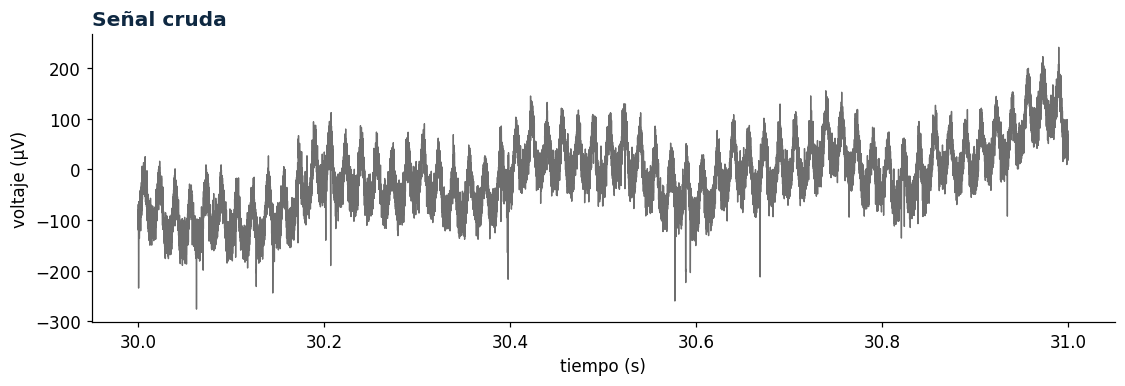

<Figure size 1320x374 with 0 Axes>

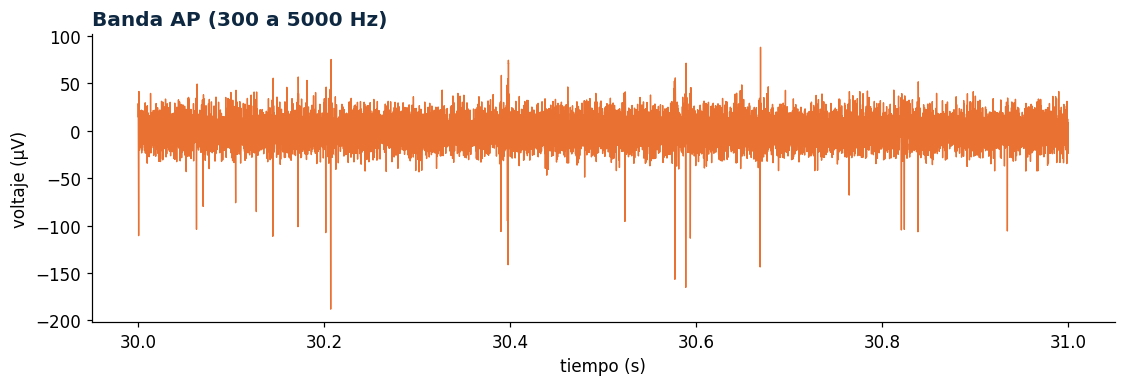

In [90]:
# Su código aquí: la función filtrar(), y con ella la banda de los potenciales de acción.
import numpy as np
from scipy import signal as sig

def filtrar_butterworth(x, fs, baja=None, alta=None, orden=3):
    """
    Filtra una señal con un filtro Butterworth de fase cero.

    Parámetros
    ----------
    x : array_like
        Señal a filtrar.
    fs : float
        Frecuencia de muestreo (Hz).
    baja : float o None
        Frecuencia de corte inferior (Hz). Si se da sola -> pasa-altos.
    alta : float o None
        Frecuencia de corte superior (Hz). Si se da sola -> pasa-bajos.
    orden : int
        Orden del filtro Butterworth (default 3).

    Retorna
    -------
    x_filt : ndarray
        Señal filtrada, del mismo tamaño que x.
    """
    if baja is None and alta is None:
        raise ValueError("Debes especificar al menos 'baja' o 'alta'.")

    nyquist = fs / 2.0

    if baja is not None and alta is not None:
        # Pasa-banda
        Wn = [baja / nyquist, alta / nyquist]
        btype = 'bandpass'
    elif alta is not None:
        # Solo hay corte superior -> pasa-bajos
        Wn = alta / nyquist
        btype = 'lowpass'
    else:
        # Solo hay corte inferior -> pasa-altos
        Wn = baja / nyquist
        btype = 'highpass'

    # Validación básica de rango (Wn debe estar en (0, 1))
    Wn_arr = np.atleast_1d(Wn)
    if np.any(Wn_arr <= 0) or np.any(Wn_arr >= 1):
        raise ValueError(
            f"Frecuencia(s) de corte fuera de rango válido (0, Nyquist={nyquist} Hz). "
            f"Wn normalizado = {Wn}"
        )

    sos = sig.butter(orden, Wn, btype=btype, output='sos')
    x_filt = sig.sosfiltfilt(sos, x)

    return x_filt

AP = filtrar_butterworth(cruda, fs, baja=300, alta=5000)      # pasa-banda de 300 a 5000 Hz sobre la señal cruda

plt.figure(); ver(cruda, "Señal cruda", t0=30.0, t1=31.0, color=GRAY)
plt.figure(); ver(AP, "Banda AP (300 a 5000 Hz)", t0=30.0, t1=31.0, color=ORANGE)

In [91]:
# ✅ VERIFICACIÓN · ejercicio D1
print(f"sigma robusta   ·   cruda: {np.median(np.abs(cruda))/0.6745:6.1f} µV"
      f"   ·   AP: {np.median(np.abs(AP))/0.6745:6.1f} µV")
print(f"potencia en 60 Hz   ·   cruda: {pot(cruda,55,65,fs):9.1f}"
      f"   ·   AP: {pot(AP,55,65,fs):9.4f}\n")

revisar("la banda AP tiene el mismo tamaño que la señal original",
        len(AP) == len(cruda), "filtfilt devuelve una señal de la misma longitud")
revisar("la banda AP botó la deriva y el LFP",
        pot(AP, 0, 50, fs) < 0.001 * pot(cruda, 0, 50, fs),
        "si sobrevive lo lento, el filtro quedó como pasa-bajos")
revisar("la banda AP botó el ruido de red de 60 Hz",
        pot(AP, 55, 65, fs) < 0.001 * pot(cruda, 55, 65, fs))
revisar("la banda AP conservó los potenciales de acción (300-3000 Hz)",
        pot(AP, 300, 3000, fs) > 0.5 * pot(cruda, 300, 3000, fs))
revisar("el ruido de la banda AP es mucho menor que el de la señal cruda",
        np.median(np.abs(AP))/0.6745 < 0.4 * (np.median(np.abs(cruda))/0.6745))

sigma robusta   ·   cruda:   70.8 µV   ·   AP:   13.5 µV
potencia en 60 Hz   ·   cruda:     413.8   ·   AP:    0.0000

  OK    la banda AP tiene el mismo tamaño que la señal original
  OK    la banda AP botó la deriva y el LFP
  OK    la banda AP botó el ruido de red de 60 Hz
  OK    la banda AP conservó los potenciales de acción (300-3000 Hz)
  OK    el ruido de la banda AP es mucho menor que el de la señal cruda


**Pregunta D2**

En la Sesión vimos que un filtro **notch** sirve para eliminar frecuencias específicas, como la de 60 Hz. Aquí no hizo falta ninguno y la
verificación acaba de decirles que la banda AP ya no tiene nada en 60 Hz.

- Miren en qué banda está el ruido de red y en qué banda están los disparos, y expliquen en
  dos líneas **por qué el pasa-banda hace el trabajo del notch** en este caso.
- ¿Qué le pasó a la deriva? ¿Y a los artefactos enormes que encontraron en la sección B?
- Entonces, ¿**cuándo** sí haría falta un notch? (Piensen qué quieren conservar.)

_Escriban su respuesta aquí:_

- El ruido de red se concentra en una banda angosta alrededor de 60 Hz y sus armónicos, mientras que los spikes tienen contenido de banda ancha por encima de ~300 Hz. Al pasa-banda tener el corte inferior en ~300 Hz (`baja=300`), ese corte ya deja todo lo que está por debajo —incluyendo 60 Hz, sus armónicos y la deriva— fuera de la señal filtrada.

- La deriva era de baja frecuencia (algo menor a 1 Hz) desaparece por el mismo componente pasa-altos del filtro (corte en ~300 Hz) que elimina todo el contenido de baja frecuencia. Mientras que los artefactos enormes de la sección B son transitorios grandes y abruptos, con energía de banda ancha, por lo que la banda AP no los elimina sino que puede generar oscilaciones espurias antes/después del artefacto por la respuesta de Butterworth ante un transitorio tan brusco.

- Si la banda de interés incluyera 60 Hz a ambos lados y no se puede cortar lo que esté por debajo como en caso de bandas gamma o beta.

### 📋 Ejercicio D3 · La otra banda: LFP, y ahí sí el notch

La respuesta a la última pregunta es: cuando lo que quieren conservar es **lo lento**. La
banda LFP vive por debajo de 300 Hz, y los 60 Hz están justo en medio: un pasa-bajos no los
puede quitar sin llevarse la señal biológica. Para eso está el *notch*, que elimina una
franja **muy angosta** y deja el resto casi intacto.

Copien este prompt **tal cual** en ChatGPT o Claude. Lean la respuesta completa antes de
usarla:

> Trabajo en Python con numpy y scipy. Tengo un array `cruda` con el voltaje (en µV) de un
> registro extracelular muestreado a 20000 Hz, contaminado con ruido de red eléctrica en
> 60 Hz y su armónico en 120 Hz. Escríbeme una función `notch(x, f0, fs, Q=30)` que use
> `scipy.signal.iirnotch` para diseñar el filtro y `scipy.signal.filtfilt` para aplicarlo.
> Explícame qué controla el parámetro `Q` y por qué en electrofisiología se usa `filtfilt`
> y no `lfilter`. Rotula todo con unidades y explícame cada línea.

Antes de correr nada, contesten: **¿el código que les dio sirve, o le sobra o le falta
algo?** Fíjense sobre todo en si le pasa la frecuencia de muestreo al diseñar el filtro:
es el error más común.

Después obtengan la banda LFP: quiten 60 y 120 Hz con el notch, y **luego** apliquen su
`filtrar()` como pasa-bajos de 300 Hz.

<Figure size 1320x374 with 0 Axes>

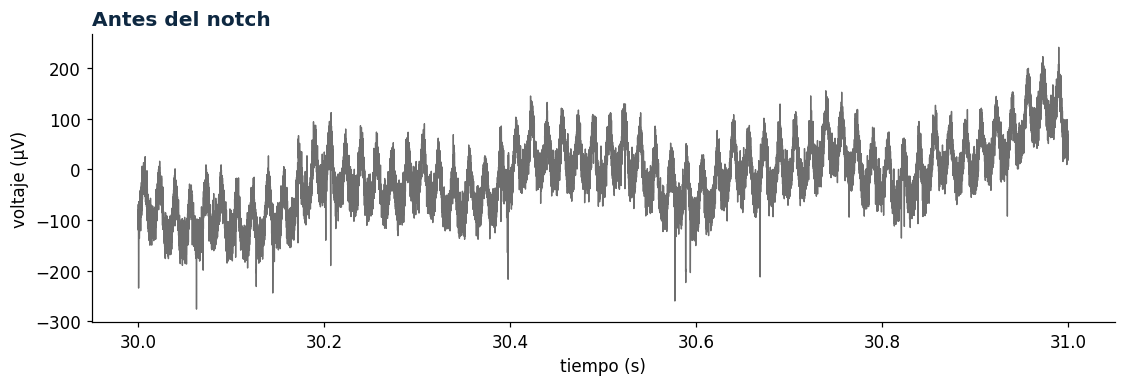

<Figure size 1320x374 with 0 Axes>

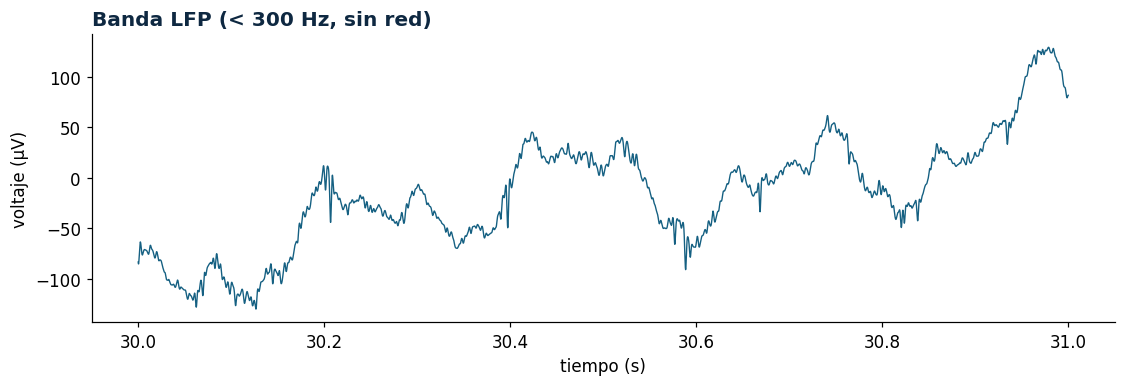

In [114]:
# Peguen aquí la función notch() (la de la IA, corregida por ustedes) y obtengan el LFP.
import numpy as np
from scipy import signal as sig


def notch(x, f0, fs, Q=30):
    """
    Aplica un filtro notch (rechaza-banda angosto) de fase cero a una señal,
    eliminando una frecuencia puntual f0 (por ejemplo, 60 Hz de ruido de red).

    Parámetros
    ----------
    x : ndarray
        Señal a filtrar, en µV (voltaje). 1D.
    f0 : float
        Frecuencia a eliminar, en Hz (ej. 60.0 para ruido de red).
    fs : float
        Frecuencia de muestreo, en Hz (ej. 20000.0).
    Q : float
        Factor de calidad del notch (adimensional). Controla qué tan
        angosta es la banda eliminada alrededor de f0. Default = 30.

    Retorna
    -------
    x_filt : ndarray
        Señal filtrada, en µV, del mismo tamaño que x.
    """
    nyquist = fs / 2.0                      # Hz, frecuencia máxima representable
    w0 = f0 / nyquist                       # adimensional, f0 normalizada a [0, 1]

    b, a = sig.iirnotch(w0, Q)              # coeficientes del filtro IIR (adimensionales)

    x_filt = sig.filtfilt(b, a, x)          # µV, señal filtrada, fase cero

    return x_filt

fs = 20000  # Hz

# Notch: Quitar ruido de red (60 Hz y su armónico en 120 Hz)
sin_60 = notch(cruda, f0=60, fs=fs, Q=30)

# Ojo: son DOS frecuencias, 60 y 120 Hz.

sin_red = notch(sin_60, f0=120, fs=fs, Q=30)    # la señal cruda sin ruido de red
LFP     = filtrar_butterworth(sin_red, fs, alta=300, orden=3) # pasa-bajos de 300 Hz sobre sin_red

plt.figure(); ver(cruda, "Antes del notch", t0=30.0, t1=31.0, color=GRAY)
plt.figure(); ver(LFP,   "Banda LFP (< 300 Hz, sin red)", t0=30.0, t1=31.0, color=TEAL)

In [115]:
# ✅ VERIFICACIÓN · ejercicio D3
caida_60  = 10*np.log10(pot(cruda,  55,  65, fs) / pot(sin_red,  55,  65, fs))
caida_120 = 10*np.log10(pot(cruda, 115, 125, fs) / pot(sin_red, 115, 125, fs))
cambio_lento = abs(10*np.log10(pot(cruda, 5, 15, fs) / pot(sin_red, 5, 15, fs)))
print(f"caída en 60 Hz: {caida_60:.1f} dB   ·   en 120 Hz: {caida_120:.1f} dB")
print(f"cambio en la banda del LFP (5-15 Hz): {cambio_lento:.2f} dB\n")

revisar("el notch bajó los 60 Hz al menos 10 dB", caida_60 > 10,
        "revisen que le pasaron fs=20000 a iirnotch")
revisar("también quitaron el armónico de 120 Hz", caida_120 > 10,
        "hay que aplicar el notch dos veces, una por cada frecuencia")
revisar("el notch NO tocó la banda del LFP", cambio_lento < 1.0,
        "si el LFP también cayó, la Q es demasiado baja: el notch quedó muy ancho")
revisar("el LFP es mucho más grande que la banda AP",
        LFP.std() > 3 * AP.std(),
        "en un registro extracelular casi toda la varianza está en lo lento")

caída en 60 Hz: 31.6 dB   ·   en 120 Hz: 24.1 dB
cambio en la banda del LFP (5-15 Hz): 0.00 dB

  OK    el notch bajó los 60 Hz al menos 10 dB
  OK    también quitaron el armónico de 120 Hz
  OK    el notch NO tocó la banda del LFP
  OK    el LFP es mucho más grande que la banda AP


**Pregunta D4.** Dos experimentos cortos y una conclusión:

- Apliquen un notch en **9 Hz**, donde sí hay señal biológica. Grafiquen antes y después y
  digan qué le pasó al LFP.
- Vuelvan al notch de 60 Hz pero con `Q = 2`. ¿Qué controla Q? Grafiquen el espectro
  resultante: ¿qué se llevó por delante?
- Repitan el pasa-banda de la banda AP moviendo el corte inferior a **100 Hz** y a
  **800 Hz**. ¿Qué se cuela con 100 Hz? ¿Qué le pasa a la **forma** de los disparos con
  800 Hz? Si tuvieran que justificar el corte de 300 Hz en un artículo, ¿qué dirían?

Con eso, contesten en una línea: **¿por qué el diagnóstico va antes del filtrado?**

_Escriban su respuesta aquí:_

- Si se aplica un notch a la zona con señal biológica estamos eliminado información

- Q controla el ancho de banda eliminado, el notch se lleva por delante todo el rango aproximado entre 40 y 80 Hz, no solo 60 Hz. Se ve un hueco ancho que eliminar un ruido de línea de forma bastante destructiva para los datos cercanos.

- Para 100 Hz se cuela info de LFP en la banda, para 800 Hz se corta información importante. El corte 300 Hz es un corte estándar en la literatura de electrofisiología debido a poder separar el contenido de la banda ancha de los potenciales de acción de el ruido de baja frecuencia sin comprometir la forma de los registros.

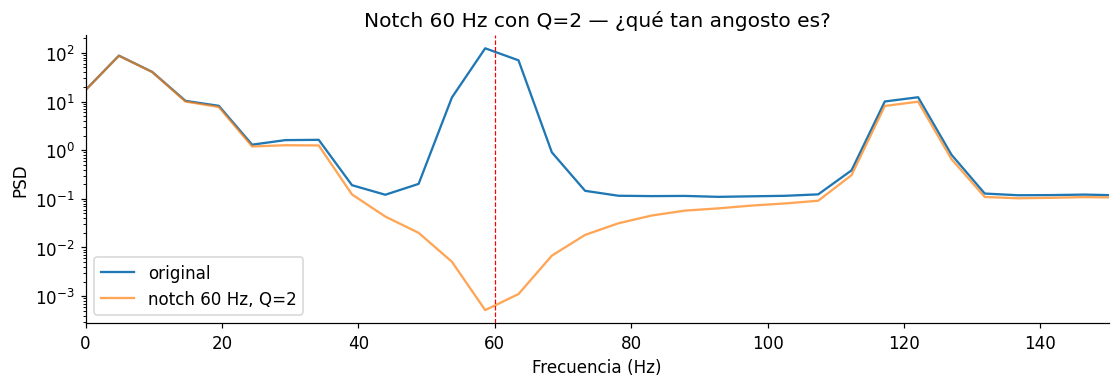

In [49]:
sesenta_Q2 = notch(cruda, f0=60, fs=fs, Q=2)

f, Pxx = sig.welch(cruda, fs=fs, nperseg=4096)
f2, Pxx2 = sig.welch(sesenta_Q2, fs=fs, nperseg=4096)

plt.semilogy(f, Pxx, label='original')
plt.semilogy(f2, Pxx2, label='notch 60 Hz, Q=2', alpha=0.7)
plt.axvline(60, color='red', ls='--', lw=0.8)
plt.xlim(0, 150)
plt.xlabel('Frecuencia (Hz)')
plt.ylabel('PSD')
plt.legend()
plt.title('Notch 60 Hz con Q=2 — ¿qué tan angosto es?')
plt.show()

/tmp/ipykernel_2619/832792638.py:22: UserWarning: Creating legend with loc="best" can be slow with large amounts of data.
  plt.tight_layout()


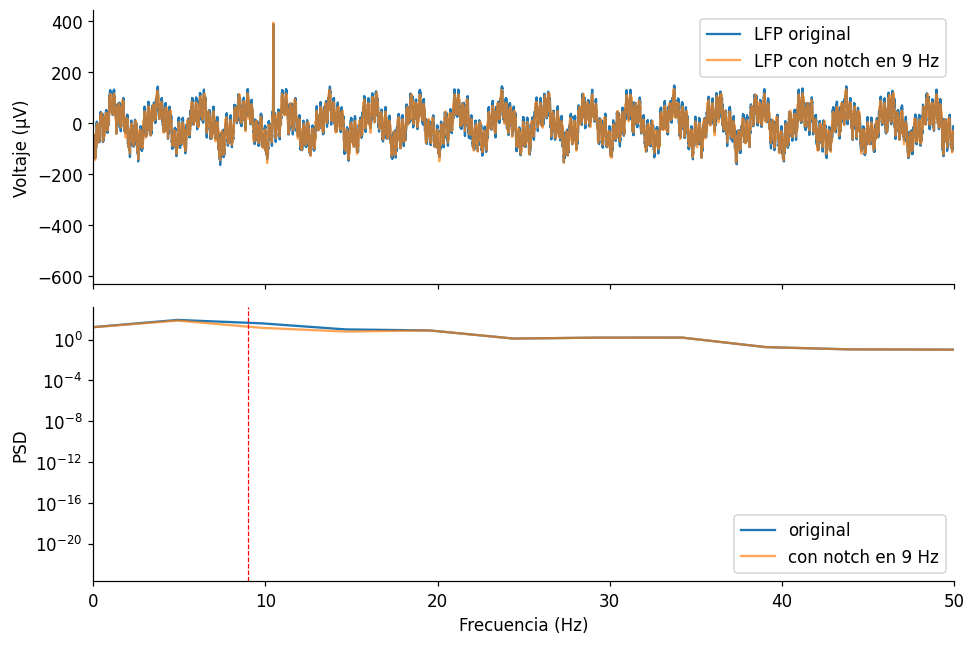

In [50]:
#Notch de 9Hz
fs = 20000  # Hz
t = np.arange(len(cruda)) / fs
lfp= filtrar_butterworth(sin_red, fs, alta=300, orden=3)
lfp_dañado = notch(lfp, f0=9, fs=fs, Q=30)

fig, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axs[0].plot(t, lfp, label='LFP original')
axs[0].plot(t, lfp_dañado, label='LFP con notch en 9 Hz', alpha=0.7)
axs[0].set_ylabel('Voltaje (µV)')
axs[0].legend()

f, Pxx = sig.welch(lfp, fs=fs, nperseg=4096)
f2, Pxx2 = sig.welch(lfp_dañado, fs=fs, nperseg=4096)
axs[1].semilogy(f, Pxx, label='original')
axs[1].semilogy(f2, Pxx2, label='con notch en 9 Hz', alpha=0.7)
axs[1].axvline(9, color='red', ls='--', lw=0.8)
axs[1].set_xlim(0, 50)
axs[1].set_xlabel('Frecuencia (Hz)')
axs[1].set_ylabel('PSD')
axs[1].legend()
plt.tight_layout()
plt.show()

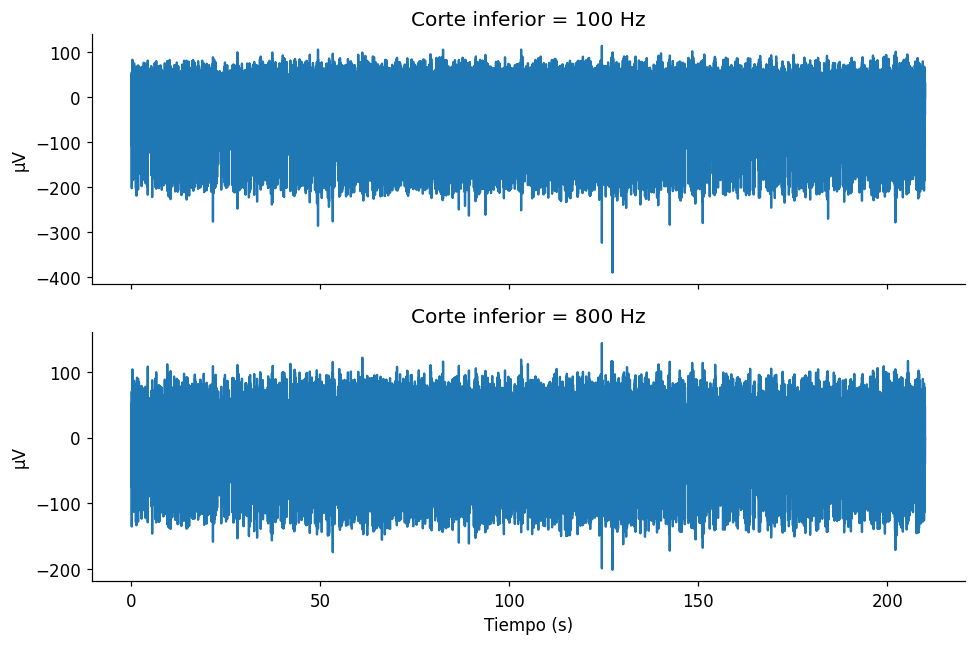

In [54]:
ap_100 = filtrar_butterworth(sin_red, fs, baja=100, alta=5000, orden=3)  # sin corte superior, o agrega uno si tu banda AP lo tenía
ap_800 = filtrar_butterworth(sin_red, fs, baja=800, alta=5000, orden=3)

fig, axs = plt.subplots(2, 1, figsize=(9, 6), sharex=True)
axs[0].plot(t, ap_100)
axs[0].set_title('Corte inferior = 100 Hz')
axs[0].set_ylabel('µV')

axs[1].plot(t, ap_800)
axs[1].set_title('Corte inferior = 800 Hz')
axs[1].set_ylabel('µV')
axs[1].set_xlabel('Tiempo (s)')
plt.tight_layout()
plt.show()

---
## E · Detectar los disparos · **el ejercicio central**

### ✏️ Ejercicio E1 · El detector

Escriban una función que reciba la señal filtrada y devuelva los índices de las muestras
donde hay un potencial de acción.

**La especificación es esta y no la pueden cambiar:**

```
detectar_spikes(x, fs, k=4.5, muerto_ms=1.5) -> np.ndarray de índices enteros
```

| | |
|---|---|
| `x` | señal **filtrada**, en µV |
| `fs` | frecuencia de muestreo, en Hz |
| `k` | cuántas veces el nivel de ruido se pone el umbral |
| `muerto_ms` | tiempo mínimo entre dos detecciones consecutivas |
| **devuelve** | los índices de las muestras donde ocurre cada disparo, ordenados y sin repetir |

**Cuatro decisiones que la función tiene que resolver.** Están enunciadas como preguntas a
propósito: si le piden a la IA "escribe un detector de spikes", casi seguro se equivocará
en al menos dos de ellas.

1. **¿Hacia dónde apunta un potencial de acción extracelular?** Miren un evento de cerca
   antes de decidir.
2. **¿Cómo se fija el umbral?** Un valor fijo en microvoltios no sirve. Hay que medir el
   ruido y poner el umbral en `k` veces esa medida. Y ojo con la trampa: la desviación
   estándar está inflada por los propios disparos. Busquen **MAD** (*median absolute
   deviation*) y por qué se divide por 0,6745:

   $$\hat{\sigma} = \frac{\text{mediana}(|x|)}{0{,}6745}, \qquad \text{umbral} = -k\,\hat{\sigma}$$

3. **Un disparo cruza el umbral durante varias muestras seguidas.** Si marcan cada muestra
   que cruza, cuentan el mismo evento muchas veces. Hay que agrupar las muestras contiguas
   y quedarse con **una** por evento. ¿Con cuál?
4. **El período muerto.** Después de marcar un evento hay que saltar `muerto_ms` hacia
   adelante. El valor por defecto, 1,5 ms, viene del período refractario de una neurona.
   En la sección F van a descubrir por qué aquí eso es discutible.

In [166]:
import numpy as np
from scipy import signal as sig
def detectar_spikes(x, fs, k=4.5, muerto_ms=1.5):
    x = np.asarray(x, dtype=float)

    sigma_hat = np.median(np.abs(x)) / 0.6745  # µV
    umbral = -k * sigma_hat                    # µV, negativo

    muerto_muestras = max(int(round(muerto_ms * fs / 1000.0)), 1)

    # Picos de -x = mínimos locales de x (los troughs de cada disparo).
    # height=-umbral porque buscamos picos de -x que superen -umbral
    # (equivale a x <= umbral). distance sigue imponiendo el período muerto,
    # pero ahora ENTRE MÍNIMOS LOCALES, no entre bordes de región.
    picos, _ = sig.find_peaks(-x, height=-umbral, distance=muerto_muestras)

    return np.sort(np.unique(picos)).astype(int)

detectar_spikes(AP, fs, 4.5, 1.5)

array([   2075,    3189,    3448, ..., 4198256, 4198682, 4199265])

In [167]:
# 1. Preparar la señal AP (si no lo tienes ya con este nombre exacto)
sin_60 = notch(cruda, f0=60, fs=fs, Q=30)
sin_ruido = notch(sin_60, f0=120, fs=fs, Q=30)
AP = filtrar_butterworth(sin_ruido, fs, baja=300, alta=None, orden=3)

# 2. Correr la detección sobre AP (no sobre sin_red, sin_ruido, ni cruda)
k = 4.5
muerto_ms = 1.5
indices = detectar_spikes(AP, fs, k=k, muerto_ms=muerto_ms)

# 3. El umbral que usa el checker debe coincidir con el que usa tu función
#    internamente — recalcúlalo igual, para pegarlo justo antes del bloque
#    de verificación que te dieron:
sigma_hat = np.median(np.abs(AP)) / 0.6745
umbral = -k * sigma_hat

In [168]:
# ✅ VERIFICACIÓN · ejercicio E1
indices = np.asarray(indices)
revisar("detectar_spikes() devuelve índices enteros, no tiempos",
        indices.dtype.kind in "iu" and indices.max() < len(AP),
        "los índices son posiciones en el array; los tiempos salen después, con indices/fs")
revisar("el número de detecciones es plausible (entre 4000 y 7000)",
        4000 <= len(indices) <= 7000,
        "si salen decenas de miles, no están agrupando los cruces; si salen cientos, el umbral es muy exigente")
revisar("todos los índices caen por debajo del umbral",
        bool(np.all(AP[indices] < umbral)),
        "están guardando el índice del cruce o del final de la ventana, no el del mínimo")
revisar("no hay dos detecciones separadas por menos del período muerto",
        bool(np.all(np.diff(indices) >= 0.0015*fs - 1)),
        "después de marcar un evento hay que saltar muerto_ms hacia adelante")
revisar("los índices salen ordenados en el tiempo",
        bool(np.all(np.diff(indices) > 0)))

  OK    detectar_spikes() devuelve índices enteros, no tiempos
  OK    el número de detecciones es plausible (entre 4000 y 7000)
  OK    todos los índices caen por debajo del umbral
  OK    no hay dos detecciones separadas por menos del período muerto
  OK    los índices salen ordenados en el tiempo


### ✏️ Ejercicio E2 · La figura de control

Una figura que muestre el resultado: la banda AP, la línea del umbral y un marcador sobre
el pico de cada disparo detectado, en una ventana de **200 ms**.

Fíjense en la línea de `d`: selecciona solo las detecciones que caen dentro de la ventana
que están graficando. Sin eso, matplotlib intenta dibujar marcadores fuera del eje y la
figura queda comprimida.

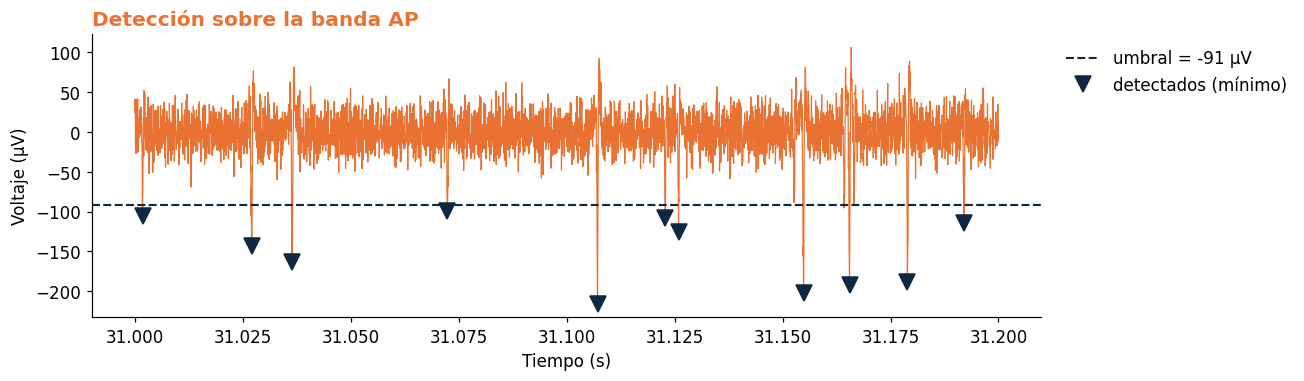

In [169]:
t0, t1 = 31.0, 31.2
m = (t >= t0) & (t < t1)

# Recalcula 'tiempos' a partir de 'indices' para asegurar que esté actualizado
tiempos = indices / fs

# Crea una máscara booleana para los picos detectados dentro de la ventana de tiempo
mask_for_window = (tiempos >= t0) & (tiempos < t1)

# 'd_abs_indices' contiene los índices absolutos de los picos en la ventana, para indexar 'AP'
d_abs_indices = indices[mask_for_window]

# 'tiempos_en_ventana' contiene los valores de tiempo de los picos en la ventana, para el eje X
tiempos_en_ventana = tiempos[mask_for_window]

plt.figure(figsize=(12, 3.6))
plt.plot(t[m], AP[m], color=ORANGE, lw=0.8)
plt.axhline(umbral, color=NAVY, ls="--", lw=1.4, label=f"umbral = {umbral:.0f} µV")
plt.plot(tiempos_en_ventana, AP[d_abs_indices], "v", color=NAVY, ms=10, ls="none", label="detectados (mínimo)")
plt.xlabel("Tiempo (s)"); plt.ylabel("Voltaje (µV)")
plt.title("Detección sobre la banda AP", color=ORANGE, fontweight="bold", loc="left")
plt.legend(frameon=False, loc="upper left", bbox_to_anchor=(1.01, 1))
plt.tight_layout()

✅ **Revisen la figura a ojo:**

- [ ] Los triángulos caen **encima** del pico de cada evento, no flotando ni desplazados.
- [ ] No hay ningún disparo evidente sin su triángulo.
- [ ] No hay triángulos sobre puntos que claramente son ruido.
- [ ] Hay leyenda y los ejes tienen unidades.

Si algo falla, arreglen la función antes de seguir: todo lo que viene la usa.

---
## F · ¿Le acertamos?

Su detector devolvió miles de instantes. Hasta aquí no saben si son buenos: *"detecté
5 400 disparos"* no dice nada por sí solo. **La pregunta es cuáles.**

### Los tres números

| | |
|---|---|
| **VP** verdadero positivo | detectaron algo y ahí había un disparo de verdad |
| **FP** falso positivo | detectaron algo donde no había nada: ruido que cruzó el umbral |
| **FN** falso negativo | había un disparo y no lo detectaron |

De ahí salen las dos medidas que van a reportar:

$$\text{precisión} = \frac{VP}{VP + FP} \qquad\qquad \text{exhaustividad} = \frac{VP}{VP + FN}$$

**Precisión** responde *de lo que detecté, ¿cuánto es real?* (si es baja, están inventando
disparos). **Exhaustividad** responde *de lo que había, ¿cuánto encontré?* (si es baja, se
les están escapando). Las dos se mueven en direcciones opuestas cuando mueven el umbral, y
ahí está toda la gracia del ejercicio F2.

### Dos detalles que casi nadie acierta a la primera

**1. La tolerancia.** Su detector no marca el evento en el instante exacto: devuelve el
instante del mínimo, que llega una fracción de milisegundo después del inicio real. Es un
desfase sistemático, no un error. Por eso no se puede exigir coincidencia exacta: hay que
fijar una **ventana de tolerancia** (aquí, 1 ms) dentro de la cual dos marcas cuentan como
la misma.

**2. No reutilizar.** Cada disparo real puede emparejarse con **una sola** detección. Si no
lo imponen, dos detecciones sobre el mismo evento cuentan las dos como aciertos y su
precisión sale inflada.

### ✍️ Ejercicio F1 · Escriban su prompt

```
emparejar(detectados_s, reales_s, tol_ms=1.0) -> (VP, FP, FN)
```

Los tiempos vienen ordenados. Escríbanla ustedes con ayuda del modelo, y **especifiquen
las dos reglas de arriba en el prompt**: si no lo hacen, el código que les devuelva va a
contar mal y va a correr perfectamente.

_Escriban aquí su prompt:_

>Escribe en Python una función: emparejar(detectados_s, reales_s, tol_ms=1.0) -> (VP, FP, FN). Debe comparar dos listas de tiempos, `detectados_s` y `reales_s`, expresados en segundos y ordenados de menor a mayor.Debe calcular VP (verdaderos positivos): detecciones que pueden emparejarse con un disparo real dentro de la ventana de tolerancia, FP (falsos positivos): detecciones que no pueden emparejarse con ningún disparo real disponible dentro de la tolerancia, FN (falsos negativos):disparos reales que no fueron detectados.

>Las reglas obligatorias son: Tolerancia:una detección y un disparo real se consideran correspondientes si la diferencia absoluta entre sus tiempos es menor o igual a `tol_ms` convertido a segundos. No se debe exigir coincidencia exacta, porque existe un desfase sistemático de aproximadamente 1 ms entre el inicio real del evento y el mínimo detectado.

>No reutilizar disparos reales:cada disparo real puede emparejarse con una sola detección. Si varias detecciones están dentro de la tolerancia de un mismo disparo real, solo una puede contar como VP; las demás deben contar como FP.

>Como los tiempos están ordenados, implementa el emparejamiento de forma eficiente, preferiblemente usando dos índices (two-pointer approach), sin comparar innecesariamente todos los pares. Devuelve únicamente la tupla `(VP, FP, FN)` y explica brevemente cómo el algoritmo garantiza las dos reglas anteriores.


In [170]:
import verificacion as v
v.usar(ARCHIVO)                       # el módulo del curso; aquí solo le pedimos la verdad

reales = v.spikes_de_referencia()     # los tiempos reales, en segundos

# Su código aquí: la función emparejar(), y con ella los tres números.
import numpy as np


def emparejar(detectados_s, reales_s, tol_ms=1.0):
    """
    Compara una lista de tiempos detectados contra una lista de tiempos
    reales (ground truth) y calcula verdaderos positivos, falsos positivos
    y falsos negativos, usando una ventana de tolerancia.

    Parámetros
    ----------
    detectados_s : array_like
        Tiempos de detección, en segundos, ordenados de menor a mayor.
    reales_s : array_like
        Tiempos de disparos reales, en segundos, ordenados de menor a mayor.
    tol_ms : float
        Tolerancia de emparejamiento, en milisegundos. Default = 1.0 ms.

    Retorna
    -------
    (VP, FP, FN) : tuple de int
        VP = verdaderos positivos, FP = falsos positivos, FN = falsos negativos.
    """
    detectados_s = np.asarray(detectados_s, dtype=float)
    reales_s = np.asarray(reales_s, dtype=float)

    tol_s = tol_ms / 1000.0  # s, tolerancia convertida de ms a s

    VP = 0
    FP = 0
    FN = 0

    i = 0  # puntero sobre detectados_s
    j = 0  # puntero sobre reales_s
    n_det = len(detectados_s)
    n_real = len(reales_s)

    while i < n_det and j < n_real:
        diff = detectados_s[i] - reales_s[j]  # s, positivo si la detección va después del real

        if diff < -tol_s:
            # La detección actual es demasiado temprana para alcanzar
            # siquiera al real más antiguo aún no emparejado. Como
            # reales_s está ordenado, ningún real futuro (más tardío)
            # va a acercarse más -> esta detección no tiene par posible.
            FP += 1
            i += 1
        elif diff > tol_s:
            # El real actual es demasiado temprano para que la detección
            # actual (o cualquier detección futura, ya que detectados_s
            # está ordenado y solo se aleja más) lo alcance -> nadie lo detectó.
            FN += 1
            j += 1
        else:
            # |diff| <= tol_s: quedan dentro de la ventana de tolerancia.
            # Se empareja esta detección con este real, y NINGUNO de los
            # dos vuelve a considerarse en iteraciones futuras.
            VP += 1
            i += 1
            j += 1

    # Lo que sobró de detectados_s (si el real ya se acabó) no tuvo con
    # qué emparejarse -> todo falso positivo.
    FP += (n_det - i)

    # Lo que sobró de reales_s (si detectados_s ya se acabó) no fue
    # alcanzado por ninguna detección -> todo falso negativo.
    FN += (n_real - j)

    return VP, FP, FN

VP, FP, FN = emparejar(tiempos, reales)
print(f"VP = {VP}   FP = {FP}   FN = {FN}")
print(f"precisión     = {VP/(VP+FP):.3f}")
print(f"exhaustividad = {VP/(VP+FN):.3f}")

Verificación configurada con: taller1_datos.h5
Cargados 5623 tiempos de spike de referencia.
Ojo: son la verdad, así que verificar_deteccion sobre ellos dará 100 %.
VP = 4596   FP = 5   FN = 1027
precisión     = 0.999
exhaustividad = 0.817


In [171]:
# ✅ VERIFICACIÓN · ejercicio F1
# El módulo del curso hace exactamente lo que ustedes acaban de programar: misma
# tolerancia de 1 ms y misma regla de no reutilizar. Sus números y los suyos TIENEN
# que coincidir. Si no coinciden, el que está mal es el de ustedes, y encontrar
# en qué es parte del ejercicio.
precision, exhaustividad = v.verificar_deteccion(tiempos)

revisar("mi precisión coincide con la del módulo",
        abs(VP/(VP+FP) - precision) < 0.002)
revisar("mi exhaustividad coincide con la del módulo",
        abs(VP/(VP+FN) - exhaustividad) < 0.002)
revisar("VP + FN es el número real de disparos",
        VP + FN == len(reales),
        "todo disparo real o lo encontraron (VP) o se les escapó (FN): no hay tercera opción")
revisar("VP + FP es el número de detecciones",
        VP + FP == len(indices),
        "toda detección o acertó (VP) o no (FP)")

  Detectaste         4601 spikes
  En realidad hay    5623
  Aciertos           4596   (tolerancia 1.0 ms)

  Precisión       99.9%  ████████████████████████████
  Exhaustividad   81.7%  ███████████████████████·····

  ▸ Vas bien, pero se puede afinar. Prueba a mover el umbral.
  OK    mi precisión coincide con la del módulo
  OK    mi exhaustividad coincide con la del módulo
  OK    VP + FN es el número real de disparos
  OK    VP + FP es el número de detecciones


### ✏️ Ejercicio F2 · El compromiso

Cambien el valor de `k` entre 3 y 8 y grafiquen precisión y exhaustividad en función de `k`,
las dos curvas en el mismo eje.

Añadan una tercera curva, el **F1**, que resume las dos en un solo número:

$$F1 = \frac{2 \cdot \text{precisión} \cdot \text{exhaustividad}}{\text{precisión} + \text{exhaustividad}}$$

Es la **media armónica** de las dos, y se usa en vez del promedio porque castiga los
desequilibrios: con precisión 1,00 y exhaustividad 0,20 el promedio daría 0,60, que suena
aceptable, mientras que el F1 da 0,33. Dicho de otro modo, el F1 solo sube cuando **las dos**
medidas son buenas a la vez.

Después contesten: **¿qué valor de `k` elegirían y por qué?** No hay una respuesta única,
pero sí hay respuestas mal argumentadas. El máximo del F1 es un punto de partida, no la
respuesta: lo que se evalúa es el argumento. Piensen en qué van a hacer después con estos
datos: ¿les duele más un disparo inventado o uno perdido?

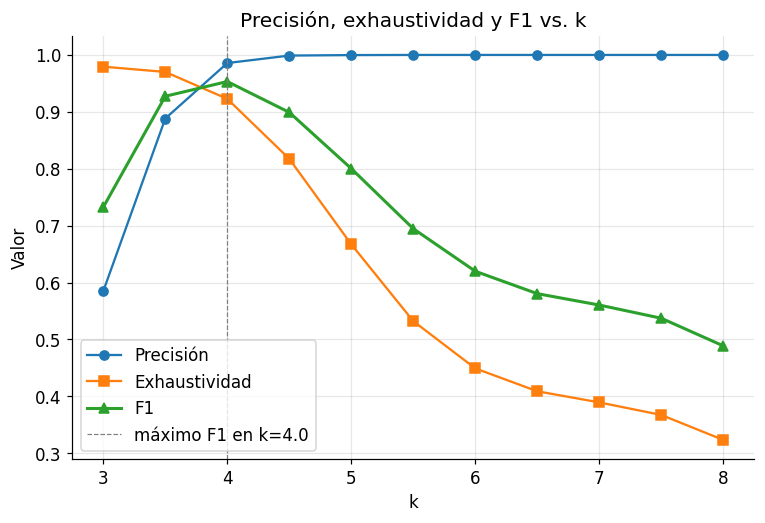

k con F1 máximo: 4.00  (F1 = 0.953)
k=3.0  precisión=0.585  exhaustividad=0.979  F1=0.733
k=3.5  precisión=0.888  exhaustividad=0.970  F1=0.927
k=4.0  precisión=0.986  exhaustividad=0.923  F1=0.953
k=4.5  precisión=0.999  exhaustividad=0.817  F1=0.899
k=5.0  precisión=1.000  exhaustividad=0.667  F1=0.800
k=5.5  precisión=1.000  exhaustividad=0.532  F1=0.695
k=6.0  precisión=1.000  exhaustividad=0.449  F1=0.620
k=6.5  precisión=1.000  exhaustividad=0.409  F1=0.580
k=7.0  precisión=1.000  exhaustividad=0.389  F1=0.560
k=7.5  precisión=1.000  exhaustividad=0.367  F1=0.537
k=8.0  precisión=1.000  exhaustividad=0.323  F1=0.489


In [172]:
import numpy as np
import matplotlib.pyplot as plt

ks = np.arange(3, 8.5, 0.5)  # de 3 a 8 en pasos de 0.5
precisiones = []
exhaustividades = []
f1s = []

for k in ks:
    indices_k = detectar_spikes(AP, fs, k=k, muerto_ms=1.5)  # muestras (int)
    tiempos_k = indices_k / fs                                # s

    VP, FP, FN = emparejar(tiempos_k, reales)

    precision = VP / (VP + FP) if (VP + FP) > 0 else 0.0
    exhaustividad = VP / (VP + FN) if (VP + FN) > 0 else 0.0
    f1 = 2 * precision * exhaustividad / (precision + exhaustividad) if (precision + exhaustividad) > 0 else 0.0

    precisiones.append(precision)
    exhaustividades.append(exhaustividad)
    f1s.append(f1)

precisiones = np.array(precisiones)
exhaustividades = np.array(exhaustividades)
f1s = np.array(f1s)

# --- Gráfica: las tres curvas en el mismo eje
plt.figure(figsize=(8, 5))
plt.plot(ks, precisiones, 'o-', label='Precisión')
plt.plot(ks, exhaustividades, 's-', label='Exhaustividad')
plt.plot(ks, f1s, '^-', label='F1', linewidth=2)
plt.axvline(ks[np.argmax(f1s)], color='gray', ls='--', lw=0.8,
            label=f'máximo F1 en k={ks[np.argmax(f1s)]:.1f}')
plt.xlabel('k')
plt.ylabel('Valor')
plt.title('Precisión, exhaustividad y F1 vs. k')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

print(f"k con F1 máximo: {ks[np.argmax(f1s)]:.2f}  (F1 = {f1s.max():.3f})")

# tabla resumen, útil para justificar la elección de k con números concretos
for k, p, r, f in zip(ks, precisiones, exhaustividades, f1s):
    print(f"k={k:.1f}  precisión={p:.3f}  exhaustividad={r:.3f}  F1={f:.3f}")

**¿Qué k elegirían?**

La precisión se satura a partir de k=5.0, pero la exhaustividad sigue bajando, de ahí en adelante únicamente se perderían más disparos reales. Por lo que las opciones de k quedan disminuídas a aquellas por debajo de 5.0. Tenemos lo svalores más altos de F1 en k=4.0 con un valor de 0.953, este punto muestra los valores más equilibrados entre exhaustividad y precisión, ambos con valores sobre 0.9, una opción que nos permite no sacrificar demasiado ninguna de las dos.

### ✏️ Ejercicio F3 · ¿De dónde salen los falsos negativos?

Tienen bastantes FN. Hay dos sospechosos, y **se pueden separar con datos**:

1. disparos **pequeños** que no alcanzaron a cruzar el umbral;
2. disparos que llegaron **dentro del período muerto** de otro, y su detector se los tragó
   porque los agrupó como un solo evento.

El segundo se comprueba directamente sobre la verdad: tomen `reales`, calculen los
intervalos entre disparos consecutivos y cuenten cuántos son más cortos que el `muerto_ms`
que usaron. Comparen ese número con su FN.

Y ahora la pregunta buena: **el período refractario es
una propiedad de una neurona.** En este registro hay **tres**, y dos neuronas distintas sí
pueden disparar con 0,3 ms de diferencia. ¿Sigue siendo válido descartar esos eventos?

Prueben a bajar `muerto_ms` a **0,4** y vuelvan a medir precisión y exhaustividad. Digan
qué ganaron y qué perdieron.

In [174]:
# Su código aquí.
reales_ordenados = np.sort(reales)  # s, por si acaso
intervalos = np.diff(reales_ordenados)  # s, entre disparos reales consecutivos

muerto_ms = 1.5
muerto_s = muerto_ms / 1000.0

n_pares_cercanos = np.sum(intervalos < muerto_s)
print(f"Pares de disparos reales separados por menos de {muerto_ms} ms: {n_pares_cercanos}")

# para comparar directamente con tu FN en k=4.0:
indices_k4 = detectar_spikes(AP, fs, k=4.0, muerto_ms=1.5)
tiempos_k4 = indices_k4 / fs
VP, FP, FN = emparejar(tiempos_k4, reales)
print(f"FN en k=4.0, muerto_ms=1.5: {FN}")
print(f"Fracción de FN explicada por período muerto: {n_pares_cercanos / FN:.2%}")

Pares de disparos reales separados por menos de 1.5 ms: 122
FN en k=4.0, muerto_ms=1.5: 434
Fracción de FN explicada por período muerto: 28.11%


In [175]:
for muerto in [1.5, 0.4]:
    idx = detectar_spikes(AP, fs, k=4.0, muerto_ms=muerto)
    t = idx / fs
    VP, FP, FN = emparejar(t, reales)
    p = VP / (VP + FP) if (VP + FP) > 0 else 0.0
    r = VP / (VP + FN) if (VP + FN) > 0 else 0.0
    f1 = 2 * p * r / (p + r) if (p + r) > 0 else 0.0
    print(f"muerto_ms={muerto}: precisión={p:.3f}  exhaustividad={r:.3f}  F1={f1:.3f}  "
          f"(VP={VP}, FP={FP}, FN={FN})")

muerto_ms=1.5: precisión=0.986  exhaustividad=0.923  F1=0.953  (VP=5189, FP=75, FN=434)
muerto_ms=0.4: precisión=0.986  exhaustividad=0.931  F1=0.958  (VP=5236, FP=77, FN=387)


**Nuestra explicación de los falsos negativos:**

| | |
|---|---|
| FN con período muerto de 1,5 ms | |
| intervalos reales más cortos que 1,5 ms | |
| FN con período muerto de 0,4 ms | |

¿Cuál de los dos sospechosos explica la mayoría? ¿Qué período muerto se quedan y por qué?

La mayoría de falsos negativos resulta ser causada por disparos pequeños, aunque un porcentaje no despreciable de los FN fue causado por el periodo muerto

---
## ⏱ Punto de control

Aquí termina el martes. **Si la detección no les quedó funcionando**, ejecuten la celda de
abajo: carga tiempos correctos para poder seguir con la separación de unidades. No penaliza
lo que viene después, pero **tienen que anotarlo en la entrega**.

Si su detección ya funciona, **sáltense esta celda**.

In [ ]:
# Descomenten SOLO si lo necesitan:
# indices = (v.spikes_de_referencia() * fs).astype(int)
# tiempos = indices / fs

---
## G · Mirar la forma de cada disparo

Hasta ahora tienen instantes. Ahora necesitan saber **cómo se ve** cada evento, porque es
lo que va a distinguir una neurona de otra.

### ✏️ Ejercicio G1 · Extraer las formas de onda

Para cada disparo detectado, extraigan una ventana de la señal **filtrada** que vaya de
**0,7 ms antes** a **1,3 ms después** del instante detectado. El resultado es una matriz de
`n_disparos × n_muestras_de_la_ventana`.

Cuidado con los eventos que caen muy al principio o muy al final del registro: la ventana
se sale del arreglo y `numpy` no avisa, simplemente devuelve algo más corto.

Después grafiquen **200 formas superpuestas** con transparencia (`alpha=0.1`) y encima la
forma promedio. El eje x en **milisegundos relativos al mínimo**, no en número de muestra.

**Miren el gráfico antes de seguir.** ¿Les parece que todas esas formas las produjo la
misma neurona?

Disparos detectados: 4601
Disparos con ventana completa (usados): 4601
Disparos descartados por borde: 0


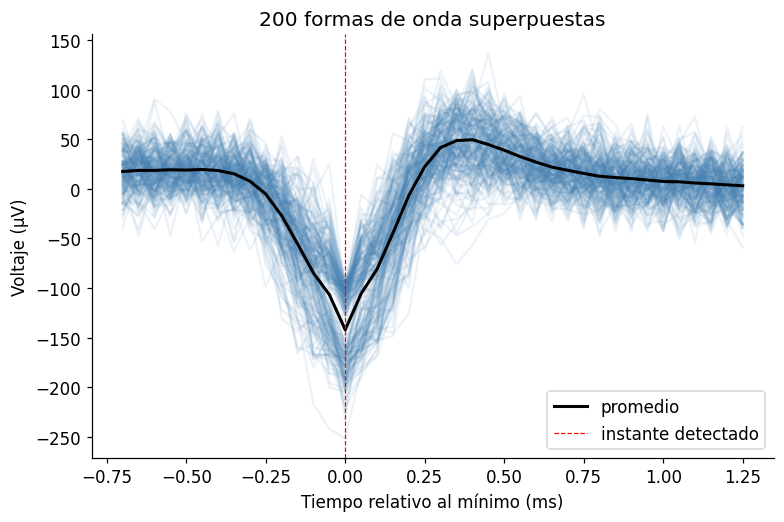

In [176]:
# Su código aquí.
import numpy as np
import matplotlib.pyplot as plt

fs = 20000  # Hz

ANTES_MS = 0.7
DESPUES_MS = 1.3

antes_muestras = int(round(ANTES_MS * fs / 1000))
despues_muestras = int(round(DESPUES_MS * fs / 1000))
n_ventana = antes_muestras + despues_muestras  # muestras totales por ventana


def extraer_formas(x, indices, antes_muestras, despues_muestras):
    """
    Extrae ventanas de la señal alrededor de cada índice detectado.

    x: señal filtrada, en µV.
    indices: índices (muestras) donde se detectó cada disparo.
    antes_muestras, despues_muestras: tamaño de la ventana a cada lado.

    Retorna: matriz (n_disparos_validos x n_ventana), en µV.
    Descarta silenciosamente los disparos cuya ventana se sale del arreglo.
    """
    x = np.asarray(x, dtype=float)
    n_ventana = antes_muestras + despues_muestras

    formas = []
    for idx in indices:
        ini = idx - antes_muestras
        fin = idx + despues_muestras

        # --- Cuidado: si no filtramos esto, x[ini:fin] cerca de los bordes
        # devuelve un segmento MÁS CORTO que n_ventana, sin avisar (numpy
        # simplemente recorta el slice), lo cual rompería el apilado en
        # una matriz rectangular más adelante.
        if ini < 0 or fin > len(x):
            continue

        formas.append(x[ini:fin])

    return np.array(formas)  # (n_disparos_validos, n_ventana), µV


formas = extraer_formas(AP, indices, antes_muestras, despues_muestras)
print(f"Disparos detectados: {len(indices)}")
print(f"Disparos con ventana completa (usados): {formas.shape[0]}")
print(f"Disparos descartados por borde: {len(indices) - formas.shape[0]}")

# --- Eje x en ms relativos al mínimo (el instante detectado cae en t=0)
t_ventana_ms = (np.arange(n_ventana) - antes_muestras) / fs * 1000  # ms

# --- Graficar 200 formas superpuestas + la forma promedio
n_mostrar = min(200, formas.shape[0])
idx_muestra = np.random.choice(formas.shape[0], size=n_mostrar, replace=False)

plt.figure(figsize=(8, 5))
for i in idx_muestra:
    plt.plot(t_ventana_ms, formas[i], color='steelblue', alpha=0.1)

promedio = formas.mean(axis=0)
plt.plot(t_ventana_ms, promedio, color='black', linewidth=2, label='promedio')

plt.axvline(0, color='red', ls='--', lw=0.8, label='instante detectado')
plt.xlabel('Tiempo relativo al mínimo (ms)')
plt.ylabel('Voltaje (µV)')
plt.title(f'{n_mostrar} formas de onda superpuestas')
plt.legend()
plt.show()
# Al final debe quedar definida la matriz de formas:

formas = extraer_formas(AP, indices, antes_muestras, despues_muestras)    # matriz n_disparos x n_muestras

# Si descartan los eventos de los bordes, descarten también su entrada en
# indices y en tiempos: de aquí en adelante los tres arreglos tienen que ir
# en el mismo orden y con el mismo tamaño.

In [177]:
# ✅ VERIFICACIÓN · ejercicio G1
n_esperado = int(0.002 * fs)
revisar("la ventana dura 2 ms",
        abs(formas.shape[1] - n_esperado) <= 1,
        "0,7 ms antes + 1,3 ms después = 2 ms = 40 muestras a 20 kHz")
revisar("hay una forma por disparo detectado (salvo los de los bordes)",
        len(indices) - 5 <= formas.shape[0] <= len(indices),
        "descarten solo los eventos cuya ventana se sale del registro")
revisar("el mínimo de la forma promedio cae dentro de la ventana, cerca del centro",
        0.2 < np.argmin(formas.mean(axis=0)) / formas.shape[1] < 0.6,
        "si el mínimo queda en el borde, la ventana está corrida: revisen el signo del desplazamiento")

  OK    la ventana dura 2 ms
  OK    hay una forma por disparo detectado (salvo los de los bordes)
  OK    el mínimo de la forma promedio cae dentro de la ventana, cerca del centro


## H · Separar las tres unidades

En este registro hay **tres neuronas**. Su tarea es decidir, para cada disparo detectado, cuál de las tres lo produjo. Eso es *spike sorting*.

**El camino corto y su problema.** Lo primero que se le ocurre a cualquiera (y lo primero que va a proponer la IA) es separar por **amplitud**: los eventos grandes de una neurona, los pequeños de otra. Pruébenlo. Van a ver que funciona para una de las tres y que las otras dos quedan mezcladas.

**Lo que hace falta.** Dos disparos pueden tener la misma altura y venir de neuronas distintas, porque tienen **forma** distinta. Necesitan al menos una característica más, medida sobre las ventanas de la sección G. Algunas ideas:

- el **ancho** del valle a media altura (en ms);
- el tiempo entre el mínimo y el máximo de la onda;
- el área bajo la curva, o la pendiente de bajada.

*(Un tetrodo tiene cuatro electrodos exactamente por esto: la misma neurona vista desde cuatro sitios da cuatro amplitudes distintas, y esa combinación la identifica. Con un solo electrodo no tienen esa información, y por eso la forma es todo lo que les queda.)*

### ¿Qué es K-means?

**K-means** es un algoritmo que permite **agrupar datos que se parecen entre sí**. En este ejercicio, cada disparo se representa mediante las características que ustedes hayan elegido, por ejemplo, amplitud y ancho del valle.

El algoritmo intenta dividir los disparos en **K grupos** (*clusters*), de manera que los disparos dentro de un mismo grupo sean lo más parecidos posible. Como en este ejercicio sabemos que hay tres neuronas, utilizaremos **K = 3**.

De forma simplificada, K-means:

1. Coloca inicialmente **3 centros** (*centroides*) en el espacio de características.
2. Asigna cada disparo al centro más cercano.
3. Recalcula cada centro como el promedio de los disparos que tiene asignados.
4. Repite los pasos 2 y 3 hasta que los grupos se estabilizan.

**Importante:** K-means no sabe qué neurona corresponde a cada grupo. Si obtiene los grupos `0`, `1` y `2`, ustedes todavía tienen que determinar qué grupo corresponde a cada unidad.

### ✏️ Ejercicio H1 · Elegir dos características y agrupar

Elijan **dos** características, hagan un gráfico de dispersión de una contra otra, y miren si aparecen grupos (*clusters*). Si aparecen, agrúpenlos (a mano con umbrales, o con `KMeans` de `sklearn`) y asignen una etiqueta a cada disparo.

**Justifiquen su elección de características en la celda de texto.** Vale más eso que el acierto que saquen.

### Pedir ayuda a la IA

Antes de aplicar K-means, pídanle ayuda a una IA para entender **cómo se calcula cada una de las características que eligieron y qué pasos deben realizar antes de utilizar K-means**.

No se trata simplemente de pedirle a la IA que les dé el código completo. Utilícenla como asistente para comprender el análisis.

Por ejemplo, pueden preguntarle:

> ¿Cómo se calcula la amplitud de un spike a partir de una ventana de señal? Explícame paso a paso y dime qué unidades tiene el resultado.

> ¿Cómo puedo calcular el ancho del valle a media altura de un spike? Explícame qué puntos de la señal necesito identificar y cómo convertir el resultado a milisegundos?

> Tengo dos características para cada spike y quiero utilizar K-means. ¿Qué pasos debo hacer antes de aplicar K-means y por qué?

Como mínimo, averigüen y documenten:

- cómo se calcula **cada una de las dos características** que eligieron;
- qué unidades tiene cada característica;
- cómo convertir las medidas de muestras a unidades de tiempo cuando sea necesario;
- cómo organizar los datos para que cada **fila corresponda a un spike** y cada **columna a una característica**;
- si es necesario **escalar o normalizar las características antes de K-means**, y por qué;
- por qué deben utilizar **K = 3** en este ejercicio.

**En la celda de texto, expliquen con sus propias palabras qué aprendieron de la IA.** Si utilizan código sugerido por la IA, asegúrense de entender qué hace cada paso.

X.shape = (4601, 2)


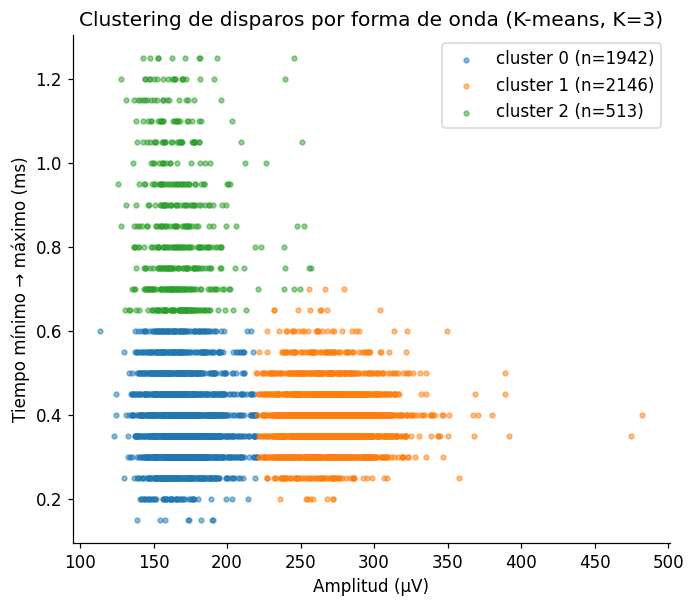

In [178]:
# Su código aquí: características, gráfico de dispersión y agrupación.
import numpy as np
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans

fs = 20000  # Hz

# --- 1. Calcular las dos características para cada disparo (fila de `formas`)

amplitudes = []      # µV
tiempos_min_max = [] # ms

for forma in formas:
    idx_min = np.argmin(forma)
    minimo = forma[idx_min]

    # buscar el máximo SOLO después del mínimo, no en toda la ventana
    idx_max_relativo = np.argmax(forma[idx_min:])
    idx_max = idx_min + idx_max_relativo
    maximo = forma[idx_max]

    amplitud = maximo - minimo            # µV
    delta_muestras = idx_max - idx_min    # muestras
    delta_ms = delta_muestras / fs * 1000 # ms

    amplitudes.append(amplitud)
    tiempos_min_max.append(delta_ms)

amplitudes = np.array(amplitudes)          # (n_disparos,), µV
tiempos_min_max = np.array(tiempos_min_max)  # (n_disparos,), ms

# --- 2. Organizar en la matriz X que espera K-means: (n_disparos, 2)
X = np.column_stack([amplitudes, tiempos_min_max])
print(f"X.shape = {X.shape}")  # (n_disparos_validos, 2)

# --- 3. Escalar antes de K-means (µV y ms tienen escalas muy distintas)
X_escalado = StandardScaler().fit_transform(X)

# --- 4. K-means con K=3 (tres neuronas conocidas de antemano)
kmeans = KMeans(n_clusters=3, random_state=0, n_init=10)
etiquetas = kmeans.fit_predict(X_escalado)  # (n_disparos,), valores en {0, 1, 2}

# --- 5. Gráfico de dispersión, coloreado por etiqueta de cluster
plt.figure(figsize=(7, 6))
colores = ['tab:blue', 'tab:orange', 'tab:green']
for cluster_id in range(3):
    mascara = etiquetas == cluster_id
    plt.scatter(amplitudes[mascara], tiempos_min_max[mascara],
                s=10, alpha=0.5, color=colores[cluster_id],
                label=f'cluster {cluster_id} (n={mascara.sum()})')

plt.xlabel('Amplitud (µV)')
plt.ylabel('Tiempo mínimo → máximo (ms)')
plt.title('Clustering de disparos por forma de onda (K-means, K=3)')
plt.legend()
plt.show()

etiquetas = kmeans.fit_predict(X_escalado)    # un identificador de unidad por disparo (0/1/2, 'a'/'b'/'c', da igual)

In [179]:
# ✅ VERIFICACIÓN · ejercicio H1
acierto = v.verificar_unidades(indices / fs, etiquetas)

  Spikes tuyos emparejados con uno real: 4596
  Unidades que propones: 3   ·   reales: 3

  Matriz de confusión (filas = tus unidades, columnas = reales)
                     U1       U2       U3
           1       2122       23        1
           0         45     1829       65
           2         17      293      201

  Acierto   90.3%  █████████████████████████···

  ▸ Separación correcta.


### ✏️ Ejercicio H2 · La matriz de confusión

La verificación les imprimió una **matriz de confusión**: filas = sus unidades, columnas =
las reales. Si dos de sus unidades se están mezclando, se ve como una fila repartida entre
dos columnas.

- ¿Cuáles se confunden y por qué?
- Repitan la agrupación usando **solo la amplitud** y comparen el acierto con el que
  obtuvieron con dos características. ¿Cuánto ganaron con la segunda?
- ¿Qué característica les habría separado mejor las dos que se mezclan?

**Nuestra lectura de la matriz:**

| | acierto |
|---|---|
| solo con amplitud | |
| con las dos características que elegimos | |

_Explicación:_

---
## I · El ISI como control de calidad

Ya tienen tres grupos. La verificación les dijo qué tan bien lo hicieron, pero **eso solo
existe con datos sintéticos**. Con un registro real nadie les va a decir el acierto:
necesitan una medida de calidad que se calcule **sin conocer la verdad**, y hay una que es
el estándar del oficio.

**El argumento.** Una neurona, después de disparar, no puede volver a disparar durante uno
o dos milisegundos: sus canales de sodio están inactivados. Es el **período refractario**, y
es biología, no convención. Entonces: si en el tren de una sola unidad aparecen intervalos
de menos de 2 ms, **esa unidad no es una neurona**. O son dos neuronas que su separación
fusionó, o el detector contó dos veces el mismo evento.

El intervalo entre disparos consecutivos se llama **ISI** (*inter-spike interval*), y la
fracción de ISI por debajo de 2 ms es la **tasa de violaciones del refractario**. En la
literatura se acepta una unidad por debajo del 0,5 a 1 %.

### ✏️ Ejercicio I1 · El ISI, junto y por unidad

**a)** Calculen el ISI de **todos** sus disparos juntos, sin separar por unidad, y la
fracción por debajo de 2 ms. Como aquí hay tres neuronas, ese número tiene que ser
claramente mayor que cero: es la prueba, **sin mirar la verdad**, de que ahí dentro hay más
de una neurona.

**b)** Ahora el ISI de **cada unidad por separado**. Si su separación es correcta, las tres
tasas deben caer cerca de cero. La que se quede alta está contaminada: tiene disparos de la
vecina.

**c)** Grafiquen el histograma de ISI de cada unidad, de 0 a 100 ms con bins de 1 ms, y
marquen los 2 ms con una línea vertical.

**d)** Vuelvan a hacer (a) y (b) con la detección de `muerto_ms = 0,4` del ejercicio F3.
¿Aparecen violaciones que antes no estaban? ¿De dónde salen?

In [ ]:
# Su código aquí.

**Nuestra lectura del ISI:**

| | violaciones < 2 ms |
|---|---|
| todos los disparos juntos | |
| unidad 1 | |
| unidad 2 | |
| unidad 3 | |

¿Alguna unidad está contaminada? ¿Cuál y por qué?

¿Qué pasó al bajar el período muerto a 0,4 ms?

---
# Segunda parte · Del tren de disparos a la figura

Hasta aquí convirtieron un archivo de voltaje en una lista de disparos con su neurona
asignada. Esa lista, por sí sola, no dice nada: es una columna de números.

Ahora la convierten en la respuesta a una pregunta: **¿cuál de las tres neuronas responde a
qué estímulo?**

Todo lo que sigue (el raster, el PSTH, el ISI, el heatmap) son cuatro maneras distintas de
mirar exactamente el mismo dato: una lista de instantes. Parte del ejercicio es entender
qué se gana y qué se pierde en cada una, y terminar armando **una figura** que las junte.

---
## J · Leer el protocolo experimental

El grupo `estimulos` dice cuándo ocurrió cada ensayo y qué se presentó. Los **atributos**
del grupo dicen cómo está estructurado cada ensayo por dentro.

### ✏️ Ejercicio J1 · Explorar el grupo estimulos

Cárguenlo y contesten, **con código**:

- ¿Cuántos ensayos hay y cuántos por condición?
- ¿Cuánto dura un ensayo? ¿Cuándo empieza el estímulo dentro del ensayo?
- ¿Están las condiciones en orden o intercaladas? **¿Por qué importa eso?**

In [ ]:
# Su código aquí.
# Pista: with h5py.File(ARCHIVO, "r") as f: ... y no olviden f["estimulos"].attrs

inicios     = ____     # instante de inicio de cada ENSAYO, en segundos
condiciones = ____     # la condición de cada ensayo ('A', 'B' o 'C')
t_pre       = ____     # cuánto dura el pre-estímulo dentro del ensayo, en segundos
t_est       = ____     # cuánto dura el estímulo, en segundos

In [ ]:
# ✅ VERIFICACIÓN · ejercicio J1
revisar("hay un inicio por ensayo y una condición por ensayo",
        len(inicios) == len(condiciones) and len(inicios) > 30)
revisar("las condiciones están intercaladas, no en bloques",
        len(set(np.asarray(condiciones)[:6].tolist())) > 1,
        "si les salen las primeras seis iguales, están leyendo mal el arreglo")
revisar("el pre-estímulo y el estímulo son positivos y menores que el ensayo",
        0 < t_est < t_pre + t_est < 5)
revisar("los ensayos no se solapan",
        bool(np.all(np.diff(np.sort(inicios)) >= t_pre + t_est)))

---
## K · De tiempo absoluto a tiempo relativo ·

Sus disparos están en tiempo absoluto: segundos desde que empezó el registro. Para comparar
ensayos entre sí eso no sirve, porque cada ensayo ocurrió en un momento distinto.

Lo que necesitan es, para cada ensayo, los disparos expresados **en tiempo relativo al
estímulo**: negativos antes de que empezara, cero justo cuando empieza, positivos después.

### ✏️ Ejercicio K1 · La función alinear()

**Especificación:**

```
alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)) -> lista de arreglos, uno por ensayo
```

⚠️ **Ojo con esto:** `inicios` marca el comienzo del **ensayo**, no el del **estímulo**. El
estímulo empieza `t_pre` segundos después. Si se saltan ese detalle, todo lo que viene
queda corrido un segundo y **los gráficos van a salir perfectamente creíbles**. Ese es el
problema: no hay error, no hay aviso, solo una conclusión equivocada.

### ✏️ Ejercicio K2 · La comprobación a mano

Comprueben a mano un ensayo cualquiera: tomen sus disparos
absolutos, réstenles el instante del estímulo y verifiquen que coinciden con lo que
devuelve su función.

In [ ]:
def alinear(tiempos, inicios, t_pre, ventana=(-1.0, 2.0)):
    """Devuelve una lista con un arreglo de tiempos relativos al estímulo por ensayo."""
    # Su código aquí.
    ...


# Un diccionario con los ensayos alineados de cada unidad, para usar de aquí en adelante
etiquetas = np.asarray(etiquetas)     # por si quedaron en una lista
alineados = {u: alinear(tiempos[etiquetas == u], inicios, t_pre) for u in np.unique(etiquetas)}

In [ ]:
# Comprobación a mano: elijan un ensayo y verifíquenlo.
# Su código aquí.

In [ ]:
# ✅ VERIFICACIÓN · ejercicios K1 y K2
u0 = np.unique(etiquetas)[0]
todos = np.concatenate(alineados[u0])
revisar("hay una lista de disparos por ensayo",
        len(alineados[u0]) == len(inicios))
revisar("todos los tiempos caen dentro de la ventana pedida",
        bool(np.all((todos >= -1.0) & (todos <= 2.0))),
        "hay que recortar cada ensayo a la ventana, no solo restar")
revisar("hay disparos antes del estímulo (tiempos negativos)",
        bool(np.any(todos < 0)),
        "la ventana empieza 1 s ANTES del estímulo: si no hay negativos, están recortando mal")
revisar("la ventana está completa en todos los ensayos",
        min(len(e) for e in alineados[u0]) >= 0 and float(todos.max()) > 1.5)

# Ojo: ninguna de estas comprobaciones puede decirles si alinearon al ensayo o al
# estímulo. Las dos versiones pasan. La única que lo detecta es la comprobación a
# mano de la celda anterior, y por eso está en la rúbrica.

---
## L · Raster

Un raster es el gráfico más honesto que existe en electrofisiología: **un punto por
disparo**, sin promediar nada. Cada fila es un ensayo, el eje horizontal es el tiempo
relativo al estímulo.

### ✏️ Ejercicio L1 · Los tres paneles del raster

Hagan una figura con **tres paneles, uno por unidad**. Dentro de cada panel agrupen los
ensayos por condición y sepárenlos visualmente (colores distintos, o bloques separados) y
marquen con una banda sombreada la ventana en que estuvo presente el estímulo.

**Pregunta L2.** Miren el resultado y contesten, **antes de calcular nada**:

- ¿Qué unidad responde al estímulo y cuál no?
- ¿Alguna responde solo a una de las tres condiciones?
- ¿Se ve la respuesta en **todos** los ensayos o solo en algunos?

*Pista de diseño: `plt.eventplot` hace esto en una línea, pero configurar los colores por
condición requiere pensar. También se puede a mano con `plt.scatter` y algo de aritmética
sobre el índice de fila.*

In [ ]:
# Su código aquí.

**Lo que leemos en el raster:**

---
## M · PSTH y el problema del bin

El PSTH (*peri-stimulus time histogram*) es el promedio de todos los ensayos: cuenta
cuántos disparos cayeron en cada intervalo de tiempo y lo convierte en **tasa de disparo**,
en disparos por segundo.

### ✏️ Ejercicio M1 · La función psth()

Escriban la función:

```
psth(ensayos_alineados, ventana, ancho_bin_s) -> (centros_de_bin, tasa_Hz)
```

Cuidado con las unidades: si cuentan disparos por bin y dividen por el número de ensayos,
tienen disparos por ensayo, **no Hz**. Falta un paso.

### ✏️ Ejercicio M2 · PSTH por unidad y condición

Grafiquen el PSTH de cada unidad y cada condición.

### ✏️ Ejercicio M3 · El efecto del bin (la parte importante)

Tomen la unidad que responde y grafiquen su PSTH con cuatro
anchos de bin: **5, 20, 50 y 200 ms**, los cuatro paneles juntos y con el mismo eje y.

Contesten: **¿cuál elegirían para una figura de un artículo, y qué información pierde cada
uno de los otros tres?** Fíjense en que con el bin más ancho la respuesta parece más
pequeña de lo que es. ¿Por qué?

In [ ]:
def psth(ensayos_alineados, ventana, ancho_bin_s):
    """Devuelve (centros_de_bin, tasa_en_Hz)."""
    # Su código aquí.
    ...

In [ ]:
# ✅ VERIFICACIÓN · ejercicio M1
u_ej = np.unique(etiquetas)[0]
c_, r_ = psth(alineados[u_ej], (-1.0, 2.0), 0.02)
n_disp = sum(len(e) for e in alineados[u_ej])
revisar("devuelve dos arrays del mismo tamaño", len(c_) == len(r_))
revisar("hay 150 bins de 20 ms en una ventana de 3 s", len(c_) == 150,
        "la ventana va de -1 a 2 s: son 3 s en total")
revisar("los centros de bin están dentro de la ventana",
        c_.min() > -1.0 and c_.max() < 2.0,
        "los centros van desplazados medio bin respecto a los bordes")
revisar("la tasa está en Hz, no en disparos por bin",
        abs(r_.mean() - n_disp/len(alineados[u_ej])/3.0) < 1.0,
        "cuentas / (n_ensayos * ancho_bin) = Hz. Si les da 50 veces menos, les falta dividir por el ancho")

In [ ]:
# Ejercicios M2 y M3: su código aquí.

**Nuestra elección de bin y por qué:**

| ancho de bin | pico del PSTH (Hz) | qué se ve · qué se pierde |
|---|---|---|
| 5 ms | | |
| 20 ms | | |
| 50 ms | | |
| 200 ms | | |

---
## N · Heatmap multiunidad

El raster muestra ensayo por ensayo y el PSTH promedia. El heatmap junta las dos cosas:
cada fila es un PSTH, y el color es la tasa de disparo.

### ✏️ Ejercicio N1 · El heatmap multiunidad

Hagan uno que muestre **todas las unidades a la vez**:

- **Filas:** una por cada combinación de unidad y condición (3 × 3 = **nueve filas**),
  agrupadas por unidad.
- **Columnas:** tiempo relativo al estímulo, con el bin que eligieron en la sección M.
- **Color:** la tasa de disparo en Hz, promediada sobre los ensayos de esa condición.

Tres decisiones que hay que tomar **y justificar**:

1. **La escala de color, ¿compartida o por fila?** Si es compartida, se pueden comparar
   unidades entre sí, pero la más callada se ve negra y no se le distingue nada. Si es por
   fila, cada una se ve bien pero ya no son comparables. Elijan una y digan qué pierden.
   *(Si normalizan por fila, dejen de rotular la barra en Hz: ya no son Hz.)*
2. **Barra de color con su unidad.** Un heatmap sin barra de color no significa nada. Y un
   mapa **secuencial** (`viridis`, `magma`), no uno divergente como `jet`: busquen por qué
   `jet` está desaconsejado en publicación científica y digan en una línea qué encontraron.
3. **Una línea vertical en t = 0** y la ventana del estímulo marcada, para que la figura se
   pueda leer sin el pie.

**Pregunta N2.** Miren la figura terminada y contesten: **¿se lee ahí, sin ayuda de nada más, cuál neurona
responde a qué?** Esa es la prueba de una buena figura.

In [ ]:
# Su código aquí.

**Lo que el heatmap muestra y el PSTH escondía:**

---
## O · La figura final · **evaluado**

Todo lo anterior fueron figuras de trabajo: sirven para entender, no para publicar. Ahora
armen **una sola figura** que resuma el taller entero y se defienda sola, como la que irá
en su póster del proyecto final.

### ✏️ Ejercicio O1 · La figura de cuatro paneles

| Panel | Contenido |
|---|---|
| **A** | las tres formas promedio, una por unidad, superpuestas y en la misma escala (la evidencia de que son tres neuronas distintas) |
| **B** | el raster de la unidad que responde, con los ensayos agrupados por condición |
| **C** | el PSTH de esa misma unidad, debajo del raster y **con el mismo eje x**, alineados |
| **D** | el heatmap multiunidad de la sección N |

**Reglas de figura científica**, y aquí sí se evalúan una por una:

- Todos los ejes con nombre **y unidad**.
- Los paneles rotulados **A, B, C, D**, arriba a la izquierda.
- B y C comparten el eje x, y se nota: las marcas de tiempo se corresponden.
- El instante del estímulo marcado en los tres paneles temporales, de la misma manera.
- Nada de texto ilegible: si al exportar a PNG no se puede leer una etiqueta, no sirve.
- Un **pie de figura** de tres o cuatro líneas, en la celda de texto de abajo. Que describa
  lo que se ve, no lo que ustedes concluyen. Miren cómo está escrito el pie de cualquier
  figura de los artículos del journal club.

Guárdenla con `plt.savefig("figuras/figura_final.png", dpi=200, bbox_inches="tight")`.

*Pista: `plt.subplots` con `gridspec_kw={"height_ratios": [...]}` y `sharex=True` para B y C.*

In [ ]:
# Su código aquí.

**Pregunta P2.** El pie de la figura:

> **Figura 1.** …

---
## P · Conclusión · **evaluado**

### ✏️ Ejercicio P1 · El párrafo de resultados

Escriban un párrafo, entre ocho y doce líneas, que conteste esta pregunta:

> **¿Qué hace cada una de las tres neuronas de este registro?**

Requisitos:

- Digan qué responde a qué **con números concretos**, no con "aumenta bastante".
- Apóyense en una figura específica: *"como se ve en el panel B…"*.
- Incluyan al menos una cosa de la que **no** estén seguros, y expliquen qué harían para
  resolverla.
- **Citen sus propias cifras de calidad**: precisión, exhaustividad y violaciones del
  refractario por unidad. Una unidad con 3 % de violaciones no sostiene la misma conclusión
  que una con 0,1 %.

Escríbanlo como el párrafo de resultados de un artículo. Es exactamente lo que van a tener
que hacer en el proyecto final.

**Resultados**

---
## Q · Su conversación con la IA · **evaluado**

### ✏️ Ejercicio Q1 · Tres intercambios documentados

Registren **al menos tres** intercambios con el modelo. Para cada uno:

- **El prompt**, copiado tal cual lo escribieron
- **Lo que devolvió**, o la parte relevante
- **Qué estaba mal**, o por qué no servía tal cual
- **Cómo lo corrigieron**, y cómo comprobaron que ahora sí

Sirven especialmente los casos en que el código **corría sin error pero estaba mal**: son
los peligrosos y son los que queremos que aprendan a detectar. Si alguno tropezó con la
alineación al inicio del ensayo en vez del estímulo, ese es el ejemplo perfecto.

---

### Intercambio 1

**Prompt:**

**Respuesta del modelo:**

**Qué estaba mal:**

**Cómo lo corregimos:**

---

### Intercambio 2

**Prompt:**

**Respuesta del modelo:**

**Qué estaba mal:**

**Cómo lo corregimos:**

---

### Intercambio 3

**Prompt:**

**Respuesta del modelo:**

**Qué estaba mal:**

**Cómo lo corregimos:**

---
## R · Entrega

La celda de abajo genera el CSV con sus disparos y sus unidades. Ejecútenla y súbanla junto
con el notebook.

**Antes de subir, revisen esto:**

**Que corra:**

- [ ] *Entorno de ejecución → Reiniciar y ejecutar todo*, y llega hasta el final **sin un
      solo error**.
- [ ] No queda ningún `____` sin llenar ni ningún `...` sin reemplazar.
- [ ] Todas las verificaciones dicen `OK`.
- [ ] Todas las figuras se ven, con ejes rotulados **y unidades**.

**Que se entienda (el código va comentado):**

- [ ] Cada función que escribieron tiene un **docstring** de una línea: qué recibe y qué
      devuelve.
- [ ] Cada línea no obvia tiene un comentario que dice **por qué**, no qué.
      `# filtro pasa-altos` sobra; `# pasa-altos a 300 Hz para quitar el LFP antes de poner
      el umbral` sirve.
- [ ] Donde haya un número mágico (300 Hz, 0,6745, 1,5 ms), el comentario dice de dónde salió.
- [ ] Las unidades están escritas (µV, ms, Hz). Es el error más caro de la electrofisiología.
- [ ] No quedan celdas muertas de pruebas a medias.

**Que sea suyo:**

- [ ] Las preguntas están contestadas **con sus palabras**.
- [ ] Los prompts que escribieron ustedes están en el notebook.
- [ ] Si usaron el punto de control de la sección F, está anotado.
- [ ] El archivo se llama `Taller1_ApellidoUno_ApellidoDos.ipynb`.

**Plazo: martes 25 de agosto de 2026**, en el repositorio de la pareja, carpeta `taller1/`.

⚠️ **Nunca peguen código que no puedan explicar en voz alta.**

### Lecturas de apoyo

- Quiroga RQ, Nadasdy Z & Ben-Shaul Y (2004). *Unsupervised spike detection and sorting
  with wavelets and superparamagnetic clustering.* Neural Computation 16:1661-1687.
- Rey HG, Pedreira C & Quiroga RQ (2015). *Past, present and future of spike sorting
  techniques.* Brain Research Bulletin 119:106-117.
- Buzsáki G, Anastassiou CA & Koch C (2012). *The origin of extracellular fields and
  currents: EEG, ECoG, LFP and spikes.* Nat Rev Neurosci 13:407-420.
- Hill DN, Mehta SB & Kleinfeld D (2011). *Quality metrics to accompany spike sorting of
  extracellular signals.* J Neurosci 31:8699-8705.

In [ ]:
tabla = pd.DataFrame({"tiempo_s": indices / fs, "unidad": np.asarray(etiquetas)})
tabla.to_csv("spikes_taller1.csv", index=False)
print(f"{len(tabla)} disparos guardados en spikes_taller1.csv")
print(tabla["unidad"].value_counts().sort_index())
tabla.head()